## Final project (3_Data analysis), Irina Zasenko

In [2]:
!pip install statsmodels

In [3]:
!pip install scikit-learn

In [11]:
import statsmodels
print(statsmodels.__version__)

0.14.5


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats


In [13]:
# Загрузка очищенных данных из файла pickle
file_path = 'data.pickle'
with open(file_path, 'rb') as f:
    dtypes_load = pickle.load(f)

# Разделение данных на отдельные переменные
calls, contacts, deals, spend = dtypes_load

### 3. Анализ временных рядов
#### 3.1. Проанализируйте тенденцию создания сделок с течением времени и их связь с звонками.
#### 3.2. Изучите распределение времени закрытия сделок и продолжительность периода от создания до закрытия.

### 4. Анализ эффективности кампаний
#### 4.1. Сравните эффективность различных маркетинговых источников Source и кампаний с точки зрения генерации лидов и коэффициента конверсии.

### 5. Анализ эффективности работы отдела продаж
#### 5.1. Оцените эффективность отдельных владельцев сделок и рекламных кампаний с точки зрения количества обработанных сделок, коэффициента конверсии и общей суммы продаж.

### 6. Анализ платежей и продуктов
#### 6.1. Изучите распределение типов оплаты и их влияние на успешность сделок.
#### 6.2. Проанализируйте популярность и успешность различных продуктов и типов обучения.

**ПЛАН РАБОТЫ:**  Перед началом анализа данных определим подходящие поля для объединения таблиц, которые нужны будут для выполнения поставленных задач, особенно в части анализа временных рядов, эффективности кампаний, работы отдела продаж и анализа платежей и продуктов.

Оптимальные поля для объединения:

CONTACTID (Calls) и Id (Contacts): для связи информации о звонках с контактами.
Contact Name (Deals) и Id (Contacts): для связи информации о сделках с контактами.
Campaign (Deals) и Campaign (Spend): для связи информации о сделках с маркетинговыми кампаниями.
Выбор типа объединения: Для объединения таблиц будем использовать тип left join, чтобы сохранить все данные из основной таблицы и добавить данные из связанной таблицы, где это возможно. Это позволяет сохранить как можно больше информации, даже если некоторые данные отсутствуют.

inner join чтобы исключить строки с отсутствующими значениями в ключевых столбцах. Это позволит нам работать только с полными наборами данных, что уменьшит вероятность возникновения проблем с отсутствующими данными при анализе. Кроме того, использование inner join гарантирует, что все объединенные строки будут содержать данные из обеих таблиц, что делает анализ более точным и надежным.

In [14]:
print("deals:", deals.shape)
print("spend:", spend.shape)
print("Уникальные Campaign в deals:", deals['Campaign'].nunique())
print("Уникальные Campaign в spend:", spend['Campaign'].nunique())
print("Топ Campaign в spend:")
print(spend['Campaign'].value_counts().head(10))

deals: (21532, 24)
spend: (19862, 6)
Уникальные Campaign в deals: 153
Уникальные Campaign в spend: 52
Топ Campaign в spend:
Campaign
Unknown                      5077
12.07.2023wide_DE            2073
02.07.23wide_DE              1685
04.07.23recentlymoved_DE     1398
youtube_shorts_DE            1223
07.07.23LAL_DE               1181
03.07.23women                1171
12.09.23interests_Uxui_DE    1143
15.07.23b_DE                  529
24.09.23retargeting_DE        504
Name: count, dtype: int64


In [35]:
print(calls.info(), "\n")
print(contacts.info(), "\n")
print(deals.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
Index: 91941 entries, 3 to 95872
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   call_id                91941 non-null  object        
 1   call_started_at        91941 non-null  datetime64[ns]
 2   manager                91941 non-null  category      
 3   contact_id             91941 non-null  object        
 4   Call Type              91941 non-null  category      
 5   call_duration_sec      91941 non-null  int32         
 6   Call Status            91941 non-null  category      
 7   Outgoing Call Status   91941 non-null  category      
 8   Scheduled in CRM       91941 non-null  category      
 9   Call Start Time 2W     91941 non-null  period[2W-SUN]
 10  Call Start Time Month  91941 non-null  period[M]     
dtypes: category(5), datetime64[ns](1), int32(1), object(2), period[2W-SUN](1), period[M](1)
memory usage: 5.0+ MB
None 

<class 

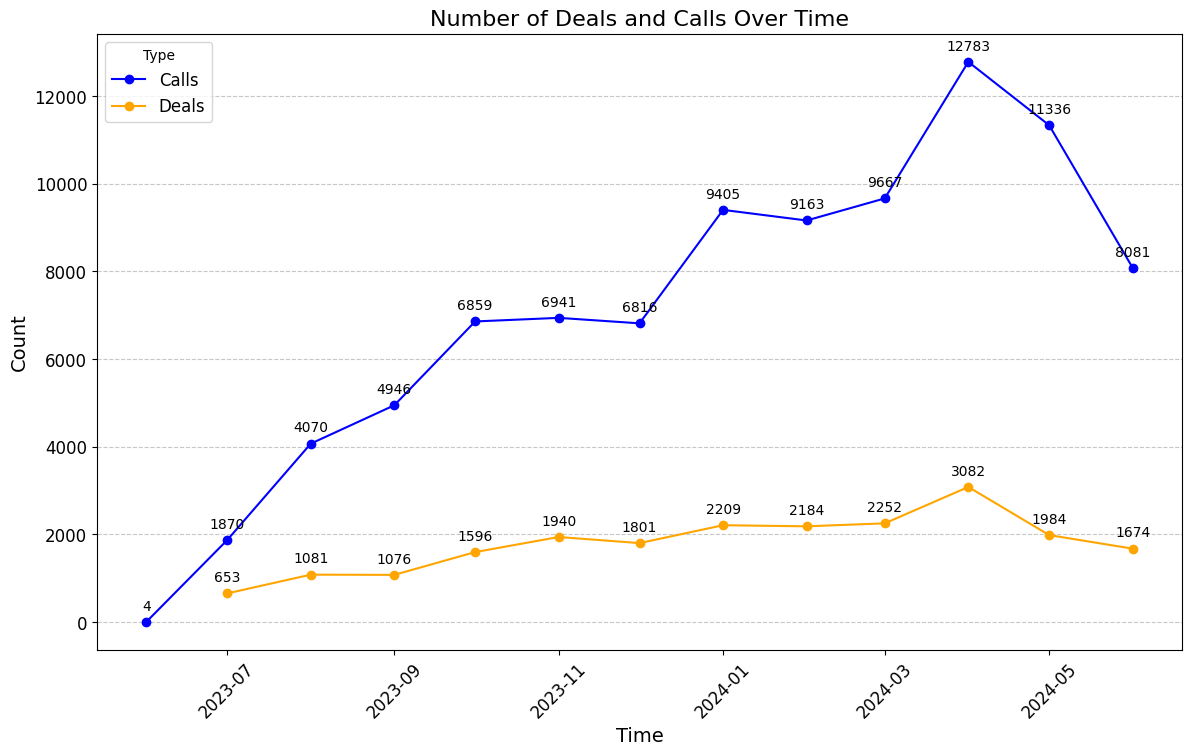

In [38]:
# Создание столбцов для периода по месяцам
calls['Call Start Time Month'] = calls['call_started_at'].dt.to_period('M')
deals['Created Time Month'] = deals['Created Time'].dt.to_period('M')

# Агрегирование данных по месяцам для звонков и сделок
calls_by_month = calls.groupby('Call Start Time Month').size().reset_index(name='Calls Count')
deals_by_month = deals.groupby('Created Time Month').size().reset_index(name='Deals Count')

# Заполнение пропущенных значений нулями
calls_by_month['Calls Count'] = calls_by_month['Calls Count'].fillna(0)
deals_by_month['Deals Count'] = deals_by_month['Deals Count'].fillna(0)

# Преобразование столбцов периода обратно в datetime для визуализации
calls_by_month['Call Start Time Month'] = calls_by_month['Call Start Time Month'].dt.to_timestamp()
deals_by_month['Created Time_x Month'] = deals_by_month['Created Time Month'].dt.to_timestamp()

# Визуализация с использованием matplotlib
plt.figure(figsize=(14, 8))
plt.plot(calls_by_month['Call Start Time Month'], calls_by_month['Calls Count'], marker='o', label='Calls', color='blue')
plt.plot(deals_by_month['Created Time_x Month'], deals_by_month['Deals Count'], marker='o', label='Deals', color='orange')

plt.title('Number of Deals and Calls Over Time', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Type', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавление меток данных
for x, y in zip(calls_by_month['Call Start Time Month'], calls_by_month['Calls Count']):
    plt.text(x, y + 200, f'{y}', ha='center', va='bottom', fontsize=10, color='black')

for x, y in zip(deals_by_month['Created Time_x Month'], deals_by_month['Deals Count']):
    plt.text(x, y + 200, f'{y}', ha='center', va='bottom', fontsize=10, color='black')

plt.show()

**Вывод:**  На графике видно, что количество звонков и количество сделок имеют разные динамики за рассматриваемый период. Количество звонков демонстрирует значительный рост с июля 2023 года, достигая пика в марте 2024 года, после чего наблюдается снижение. В то же время, количество сделок также растет, но более плавно, с менее выраженными пиками. Максимальное значение сделок также приходится на март 2024 года, что может указывать на корреляцию между активностью звонков и количеством заключаемых сделок. Общее количество сделок заметно ниже по сравнению с количеством звонков, что подчеркивает значимость эффективности конвертации звонков в успешные сделки.


Для более детального анализа построим временной ряд с интервалом в две недели, а затем проведем декомпозицию, чтобы выявить тренды и сезонность.
Построение временного ряда с интервалом в две недели позволяет лучше видеть изменения и тренды в данных, поскольку более мелкий интервал дает более детализированное представление о данных.

Декомпозиция временного ряда помогает выявить три компонента:

Тренд (Trend) -общее направление временного ряда
Сезонность (Seasonal) - периодические колебания
Остаток (Residual) - случайные колебания, которые не объясняются трендом и сезонностью

Построим временной ряд с интервалом в две недели

Выполним декомпозицию временного ряда

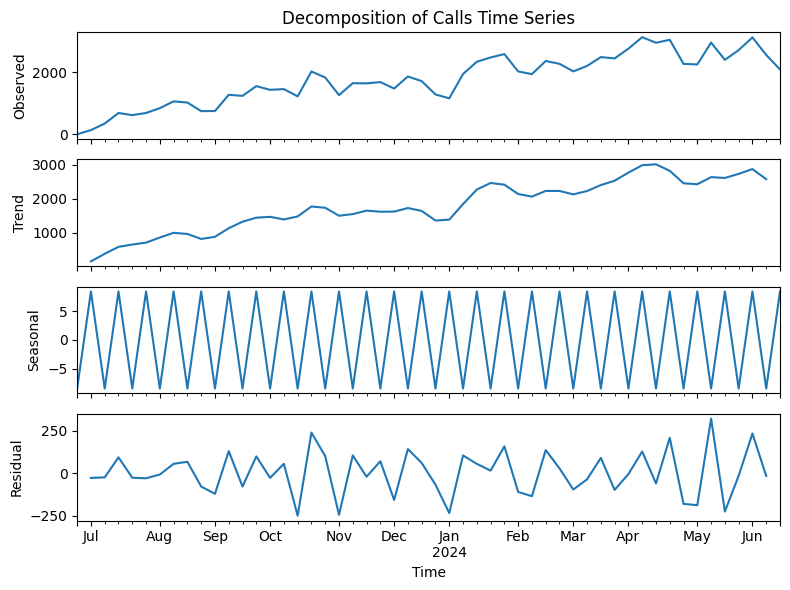

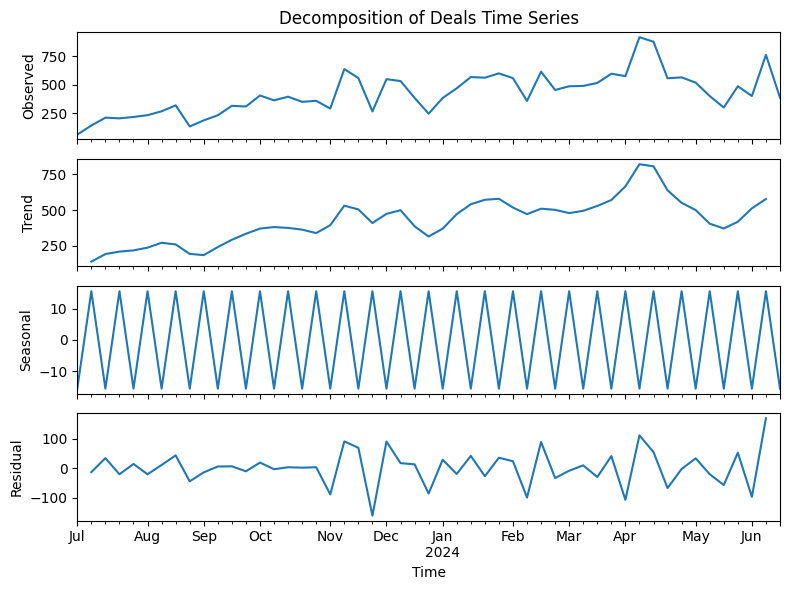

In [39]:
# Создание столбцов для периода по 2 неделям
calls['Call Start Time 2W'] = calls['call_started_at'].dt.to_period('2W')
deals['Created Time_x 2W'] = deals['Created Time'].dt.to_period('2W')

# Агрегирование данных по 2 неделям для звонков и сделок
calls_by_2weeks = calls.groupby('Call Start Time 2W').size().reset_index(name='Calls Count')
deals_by_2weeks = deals.groupby('Created Time_x 2W').size().reset_index(name='Deals Count')

# Преобразование столбцов периода обратно в datetime для визуализации
calls_by_2weeks['Call Start Time 2W'] = calls_by_2weeks['Call Start Time 2W'].dt.to_timestamp()
deals_by_2weeks['Created Time_x 2W'] = deals_by_2weeks['Created Time_x 2W'].dt.to_timestamp()

# Установка индексов для декомпозиции
calls_by_2weeks.set_index('Call Start Time 2W', inplace=True)
deals_by_2weeks.set_index('Created Time_x 2W', inplace=True)

# Выполнение декомпозиции
decomposition_calls = seasonal_decompose(calls_by_2weeks['Calls Count'], model='additive', period=2)
decomposition_deals = seasonal_decompose(deals_by_2weeks['Deals Count'], model='additive', period=2)

# Функция для визуализации декомпозиции
def plot_decomposition(decomposition, title):
    fig, axes = plt.subplots(4, 1, figsize=(8, 6), sharex=True)
    decomposition.observed.plot(ax=axes[0], legend=False)
    axes[0].set_ylabel('Observed')
    axes[0].set_title(title)

    decomposition.trend.plot(ax=axes[1], legend=False)
    axes[1].set_ylabel('Trend')

    decomposition.seasonal.plot(ax=axes[2], legend=False)
    axes[2].set_ylabel('Seasonal')

    decomposition.resid.plot(ax=axes[3], legend=False)
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Time')

    plt.tight_layout()
    plt.show()

# Визуализация декомпозиции для звонков
plot_decomposition(decomposition_calls, 'Decomposition of Calls Time Series')

# Визуализация декомпозиции для сделок
plot_decomposition(decomposition_deals, 'Decomposition of Deals Time Series')

**ПЛАН РАБОТЫ:**

Общий тренд (Trend):

Для сделок также наблюдается положительный тренд, однако он менее выражен, что может указывать на более стабильный рост по сравнению с количеством звонков.
Сезонность (Seasonal):

Оба временных ряда показывают наличие выраженной сезонности с периодическими колебаниями каждые две недели. Это может быть связано с регулярными маркетинговыми кампаниями, акциями или другими факторами, влияющими на поведение клиентов.
Поскольку сезонные колебания есть, можно предложить планировать маркетинговые кампании с учетом выявленных циклов для максимального охвата целевой аудитории.
Остатки (Residual):

Остатки показывают случайные колебания, которые не объясняются трендом или сезонностью. Временные ряды остаточных компонентов для звонков и сделок указывают на наличие нерегулярных событий, которые могут влиять на количество звонков и сделок.
Рассмотрение факторов, которые могут влиять на случайные колебания, поможет снизить их влияние и повысить стабильность показателей.



### 3.2. Изучить распределение времени закрытия сделок и продолжительность периода от создания до закрытия.
Рассчитаем продолжительность периода от создания до закрытия сделки.
Построим графики, показывающие распределение времени закрытия сделок и продолжительности этих периодов.

Для дальнейшего анализа данных определим подходящие поля для объединения таблиц, которые нужны будут для выполнения поставленных задач, особенно в части анализа временных рядов, эффективности кампаний, работы отдела продаж и анализа платежей и продуктов.

Оптимальные поля для объединения:

Contact Name (Deals) и Id (Contacts): для связи информации о сделках с контактами. 

Campaign (Deals) и Campaign (Spend): для связи информации о сделках с маркетинговыми кампаниями. Выбор типа объединения: Для объединения таблиц будем использовать тип left join, чтобы сохранить все данные из основной таблицы и добавить данные из связанной таблицы, где это возможно. Это позволяет сохранить как можно больше информации, даже если некоторые данные отсутствуют.

inner join чтобы исключить строки с отсутствующими значениями в ключевых столбцах. Это позволит нам работать только с полными наборами данных, что уменьшит вероятность возникновения проблем с отсутствующими данными при анализе. Кроме того, использование inner join гарантирует, что все объединенные строки будут содержать данные из обеих таблиц, что делает анализ более точным и надежным.

In [40]:
deals.info()
deals.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21532 entries, 0 to 21592
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          21532 non-null  object        
 1   Deal Owner Name             21532 non-null  category      
 2   Closing Date                14605 non-null  datetime64[ns]
 3   Quality                     21532 non-null  category      
 4   Stage                       21532 non-null  category      
 5   Lost Reason                 21532 non-null  category      
 6   Page                        21532 non-null  category      
 7   Campaign                    21532 non-null  category      
 8   SLA                         21532 non-null  int64         
 9   Content                     21532 non-null  category      
 10  Term                        21532 non-null  category      
 11  Source                      21532 non-null  category      


,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,...,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,Deutsch Level (Normalized),Created Time_x 2W,Created Time Month
0,5805028000056864695,Ben Hall,NaT,Unknown,New Lead,Unknown,/eng/test,03.07.23women,0,v16,...,11,5,1000,11000,5805028000056849495,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06
1,5805028000056859489,Ulysses Adams,NaT,Unknown,New Lead,Unknown,/at-eng,Unknown,0,Unknown,...,6,5,0,2000,5805028000056834471,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,/at-eng,engwien_AT,1603,b1-at,...,11,5,1000,11000,5805028000056854421,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06
3,5805028000056824246,Eva Kent,2024-06-21,E - Non Qualified,Lost,Invalid number,/eng,04.07.23recentlymoved_DE,3604,bloggersvideo14com,...,11,5,1000,11000,5805028000056889351,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06
4,5805028000056873292,Ben Hall,2024-06-21,D - Non Target,Lost,Non target,/eng,discovery_DE,3192,website,...,11,5,1000,11000,5805028000056876176,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06


In [41]:
contacts.info()
contacts.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   contact_id          18548 non-null  object        
 1   contact_owner_name  18548 non-null  category      
 2   created_time        18548 non-null  datetime64[ns]
 3   modified_time       18548 non-null  datetime64[ns]
 4   Created Time Month  18548 non-null  period[M]     
dtypes: category(1), datetime64[ns](2), object(1), period[M](1)
memory usage: 598.1+ KB


,contact_id,contact_owner_name,created_time,modified_time,Created Time Month
0,5805028000000645014,Rachel White,2023-06-27 11:28:00,2023-12-22 13:34:00,2023-06
1,5805028000000872003,Charlie Davis,2023-07-03 11:31:00,2024-05-21 10:23:00,2023-07
2,5805028000000889001,Bob Brown,2023-07-02 22:37:00,2023-12-21 13:17:00,2023-07
3,5805028000000907006,Bob Brown,2023-07-03 05:44:00,2023-12-29 15:20:00,2023-07
4,5805028000000939010,Nina Scott,2023-07-04 10:11:00,2024-04-16 16:14:00,2023-07


In [42]:
spend.info()
spend.head()

<class 'pandas.core.frame.DataFrame'>
Index: 19862 entries, 0 to 20778
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         19862 non-null  datetime64[ns]
 1   Source       19862 non-null  category      
 2   Campaign     19862 non-null  category      
 3   Impressions  19862 non-null  Int64         
 4   Spend        19862 non-null  float64       
 5   Clicks       19862 non-null  Int64         
dtypes: Int64(2), category(2), datetime64[ns](1), float64(1)
memory usage: 856.0 KB


,Date,Source,Campaign,Impressions,Spend,Clicks
0,2023-07-03,Google Ads,gen_analyst_DE,6,0.00,0
1,2023-07-03,Google Ads,performancemax_eng_DE,4,0.01,1
2,2023-07-03,Facebook Ads,Unknown,0,0.00,0
3,2023-07-03,Google Ads,Unknown,0,0.00,0
4,2023-07-03,CRM,Unknown,0,0.00,0


In [44]:
deals_contacts = pd.merge(deals, contacts, left_on='Contact Name', right_on='contact_id', how='left')

In [45]:
deals_contacts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21532 entries, 0 to 21531
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          21532 non-null  object        
 1   Deal Owner Name             21532 non-null  category      
 2   Closing Date                14605 non-null  datetime64[ns]
 3   Quality                     21532 non-null  category      
 4   Stage                       21532 non-null  category      
 5   Lost Reason                 21532 non-null  category      
 6   Page                        21532 non-null  category      
 7   Campaign                    21532 non-null  category      
 8   SLA                         21532 non-null  int64         
 9   Content                     21532 non-null  category      
 10  Term                        21532 non-null  category      
 11  Source                      21532 non-null  category  

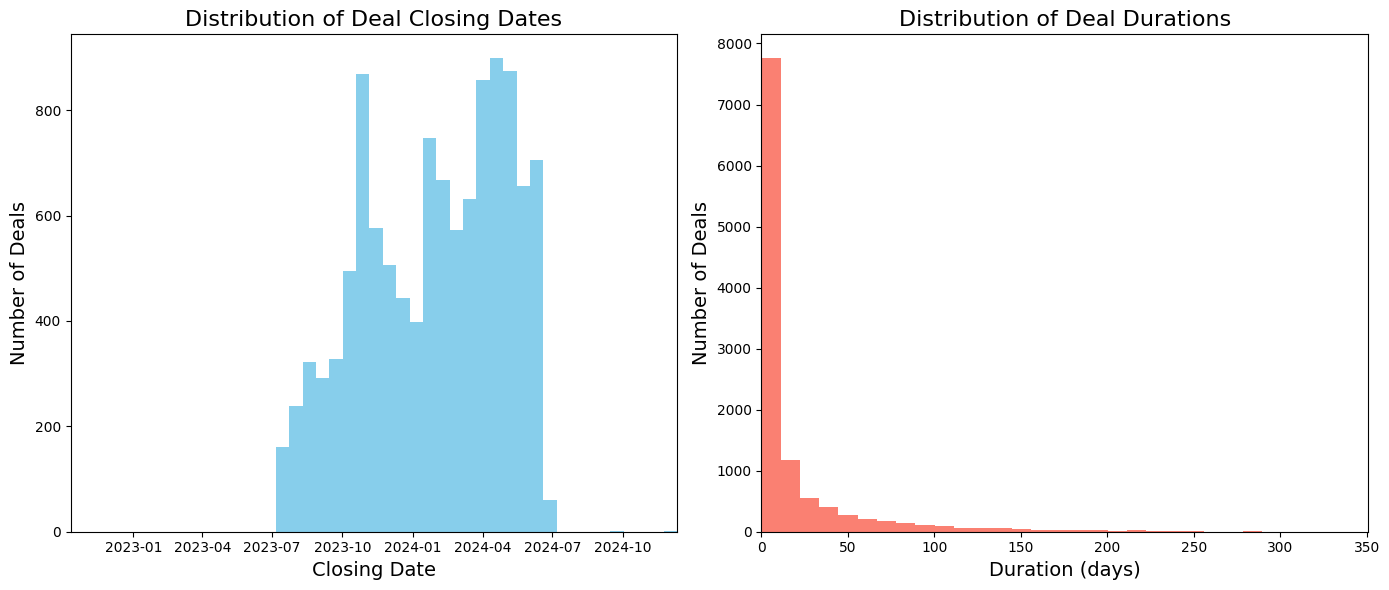

In [47]:
# Расчет продолжительности периода от создания до закрытия сделки
deals_contacts['Duration'] = (deals_contacts['Closing Date'] - deals_contacts['Created Time']).dt.days

# Определение временных рамок для графиков
min_date = deals_contacts['Closing Date'].min()
max_date = deals_contacts['Closing Date'].max()

# Фильтрация данных по продолжительности (удаление отрицательных значений)
deals_contacts_filtered = deals_contacts[deals_contacts['Duration'] >= 0]

# Визуализация распределения времени закрытия сделок
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(deals_contacts_filtered['Closing Date'], bins=30, color='skyblue')
plt.title('Distribution of Deal Closing Dates', fontsize=16)
plt.xlabel('Closing Date', fontsize=14)
plt.ylabel('Number of Deals', fontsize=14)
plt.xlim([min_date, max_date])  # Ограничение временных рамок

# Визуализация распределения продолжительности периода от создания до закрытия сделки
plt.subplot(1, 2, 2)
plt.hist(deals_contacts_filtered['Duration'], bins=30, color='salmon')
plt.title('Distribution of Deal Durations', fontsize=16)
plt.xlabel('Duration (days)', fontsize=14)
plt.ylabel('Number of Deals', fontsize=14)
plt.xlim(left=0)  # Ограничение временных рамок для исключения отрицательных значений

plt.tight_layout()
plt.show()

**Вывод:**
График распределения дат закрытия сделок показывает, что количество закрытых сделок увеличивается с начала 2024 года, достигая пиков в феврале и апреле 2024 года. В другие месяцы количество закрытых сделок более равномерно распределено, но с меньшим числом сделок в каждом месяце. Это может указывать на сезонные колебания или влияния определенных факторов в эти периоды, которые способствуют увеличению закрытых сделок.

Распределение продолжительности периодов от создания до закрытия сделки показывает, что большинство сделок закрываются в течение первых 10 дней после их создания, что свидетельствует о высокой эффективности процесса продаж. Однако, есть несколько сделок, которые закрываются спустя более длительные периоды, вплоть до 140 дней, хотя такие случаи редки. Основная масса сделок закрывается относительно быстро, что говорит об эффективных процессах работы с клиентами, но длительные периоды закрытия некоторых сделок требуют дополнительного анализа для улучшения этих процессов.

# 4. Анализ эффективности кампаний
### 4.1. Сравните эффективность различных маркетинговых источников Source и кампаний с точки зрения генерации лидов и коэффициента конверсии.


Для анализа эффективности кампаний с точки зрения генерации лидов и коэффициента конверсии объединим таблицы deals и spend, чтобы рассчитать необходимые метрики.

In [48]:
print("Столбцы в spend:", spend.columns.tolist())

# Найти столбец с суммой
possible_amount_cols = ['amount', 'cost', 'spend', 'budget', 'expenses', 'amounts', 'total']
amount_col = None

for col in spend.columns:
    if col.lower().strip() in possible_amount_cols:
        amount_col = col
        break

if amount_col is None:
    raise ValueError("❌ Не найден столбец с суммой расходов в 'spend'")

print(f"✅ Используем столбец: {amount_col}")

# Агрегируем spend
spend_agg = spend.groupby('Campaign', as_index=False, observed=False).agg({
    amount_col: 'sum',
    'Date': 'min'  # или уберите, если не нужно
})

spend_agg.rename(columns={amount_col: 'Total spend'}, inplace=True)

# Объединяем с deals
deals_spend = pd.merge(deals, spend_agg, on='Campaign', how='left')

print("✅ Объединение прошло успешно!")
print("Размер deals_spend:", deals_spend.shape)
print("Столбцы в deals_spend:", deals_spend.columns.tolist())

Столбцы в spend: ['Date', 'Source', 'Campaign', 'Impressions', 'Spend', 'Clicks']
✅ Используем столбец: Spend
✅ Объединение прошло успешно!
Размер deals_spend: (21532, 28)
Столбцы в deals_spend: ['Id', 'Deal Owner Name', 'Closing Date', 'Quality', 'Stage', 'Lost Reason', 'Page', 'Campaign', 'SLA', 'Content', 'Term', 'Source', 'Payment Type', 'Product', 'Education Type', 'Created Time', 'Course duration', 'Months of study', 'Initial Amount Paid', 'Offer Total Amount', 'Contact Name', 'City', 'Level of Deutsch', 'Deutsch Level (Normalized)', 'Created Time_x 2W', 'Created Time Month', 'Total spend', 'Date']


In [49]:
deals_spend.head()

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Page,Campaign,SLA,Content,...,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,Deutsch Level (Normalized),Created Time_x 2W,Created Time Month,Total spend,Date
0,5805028000056864695,Ben Hall,NaT,Unknown,New Lead,Unknown,/eng/test,03.07.23women,0,v16,...,1000,11000,5805028000056849495,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06,4219.75,2023-07-03
1,5805028000056859489,Ulysses Adams,NaT,Unknown,New Lead,Unknown,/at-eng,Unknown,0,Unknown,...,0,2000,5805028000056834471,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06,27887.68,2023-07-03
2,5805028000056832357,Ulysses Adams,2024-06-21,D - Non Target,Lost,Non target,/at-eng,engwien_AT,1603,b1-at,...,1000,11000,5805028000056854421,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06,NaN,NaT
3,5805028000056824246,Eva Kent,2024-06-21,E - Non Qualified,Lost,Invalid number,/eng,04.07.23recentlymoved_DE,3604,bloggersvideo14com,...,1000,11000,5805028000056889351,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06,4523.31,2023-07-06
4,5805028000056873292,Ben Hall,2024-06-21,D - Non Target,Lost,Non target,/eng,discovery_DE,3192,website,...,1000,11000,5805028000056876176,nan,Unknown,NaN,2024-06-17/2024-06-23,2024-06,9750.63,2023-09-15


In [50]:
deals_spend.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21532 entries, 0 to 21531
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Id                          21532 non-null  object        
 1   Deal Owner Name             21532 non-null  category      
 2   Closing Date                14605 non-null  datetime64[ns]
 3   Quality                     21532 non-null  category      
 4   Stage                       21532 non-null  category      
 5   Lost Reason                 21532 non-null  category      
 6   Page                        21532 non-null  category      
 7   Campaign                    21532 non-null  object        
 8   SLA                         21532 non-null  int64         
 9   Content                     21532 non-null  category      
 10  Term                        21532 non-null  category      
 11  Source                      21532 non-null  category  

In [51]:
# Нормализуем: приводим к строке, убираем пробелы, в нижний регистр
source_normalized = deals_spend['Source'].astype(str).str.strip().str.lower()


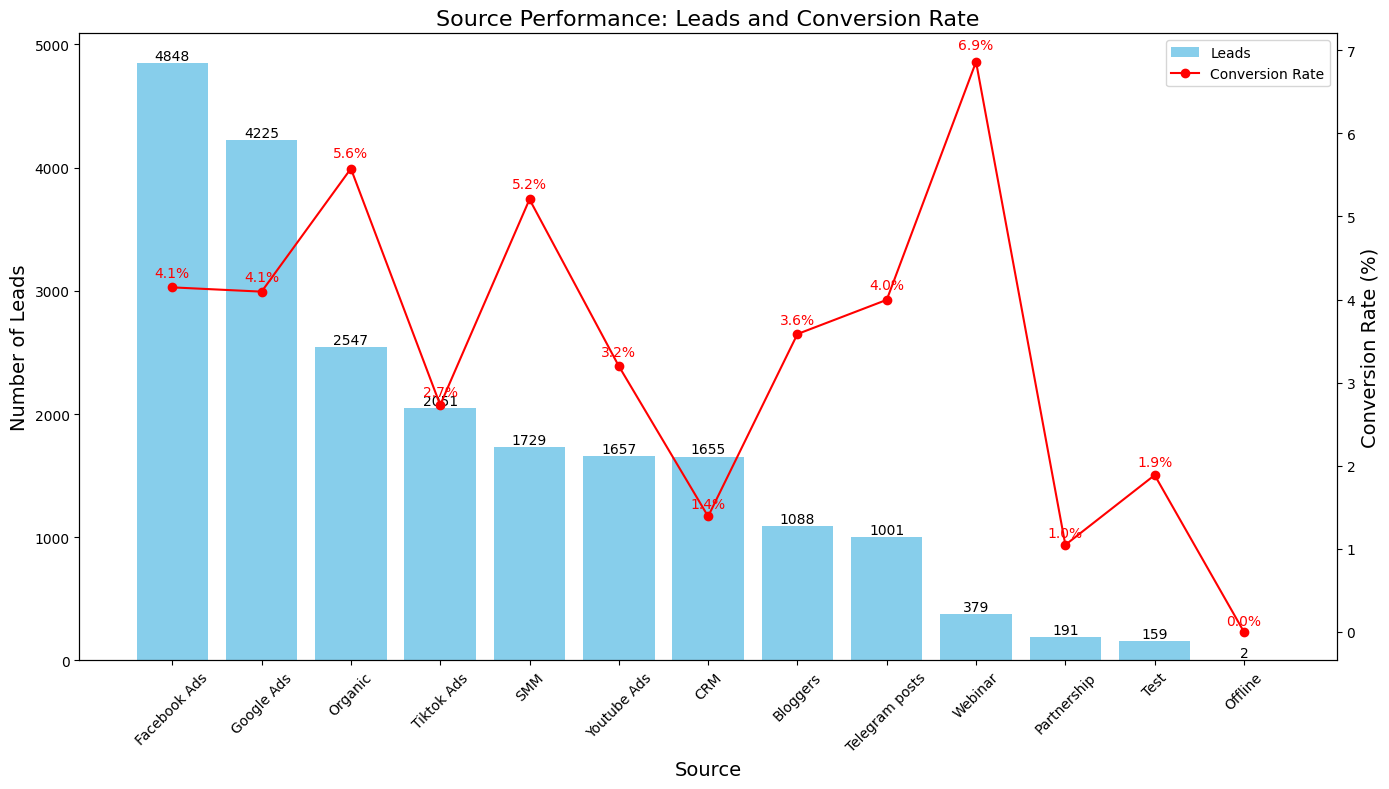

Средний Conversion Rate: 3.94%


In [52]:
# Рассчет количества лидов для каждого источника
source_leads = deals_spend.groupby('Source', observed=True).size().reset_index(name='Leads')

# Рассчет количества успешных сделок для каждого источника
successful_deals = deals_spend[deals_spend['Stage'] == 'Payment Done'].groupby('Source', observed=True).size().reset_index(name='Successful Deals')

# Объединение данных для расчета коэффициента конверсии
source_performance = pd.merge(source_leads, successful_deals, on='Source', how='left')

# Расчет коэффициента конверсии
source_performance['Successful Deals'] = source_performance['Successful Deals'].fillna(0)
source_performance['Conversion Rate'] = source_performance['Successful Deals'] / source_performance['Leads'] * 100

# Сортировка по количеству лидов (по убыванию)
source_performance = source_performance.sort_values(by='Leads', ascending=False).reset_index(drop=True)

# Визуализация
fig, ax1 = plt.subplots(figsize=(14, 8))

# Количество лидов (столбчатая диаграмма)
ax1.set_title('Source Performance: Leads and Conversion Rate', fontsize=16)
ax1.set_xlabel('Source', fontsize=14)
ax1.set_ylabel('Number of Leads', fontsize=14)
bars = ax1.bar(source_performance['Source'], source_performance['Leads'], color='skyblue', label='Leads')
ax1.tick_params(axis='x', rotation=45)

# Убираем grid у первой оси
ax1.grid(False)

# Коэффициент конверсии (линейный график)
ax2 = ax1.twinx()
ax2.set_ylabel('Conversion Rate (%)', fontsize=14)
line, = ax2.plot(source_performance['Source'], source_performance['Conversion Rate'], color='red', marker='o', label='Conversion Rate')

# Убираем grid у второй оси
ax2.grid(False)

# Легенда
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

# Метки данных: лиды
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=10, color='black')

# Метки данных: конверсия (чуть выше точек)
for i, (x, y) in enumerate(zip(source_performance['Source'], source_performance['Conversion Rate'])):
    ax2.text(i, y + (y * 0.01 + 0.05),  # смещение 0.5% от значения + небольшой запас
             f"{y:.1f}%", ha='center', va='bottom', fontsize=10, color='red')

plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.show()
# Средний уровень конверсии
avg_conversion = source_performance['Successful Deals'].sum() / source_performance['Leads'].sum() * 100
print(f"Средний Conversion Rate: {avg_conversion:.2f}%")

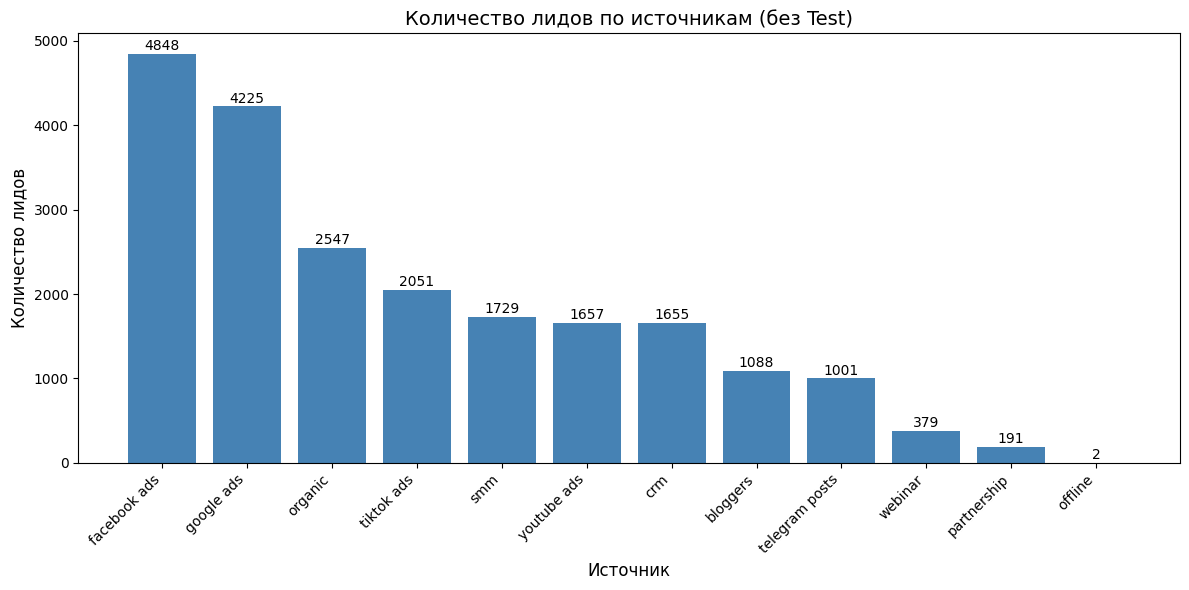

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Фильтрация: исключаем 'Test' (с учётом регистра и пробелов)
deals_spend['Source'] = deals_spend['Source'].astype(str).str.strip().str.lower()
filtered_df = deals_spend[deals_spend['Source'] != 'test']

# 2. Группировка по 'Source' и подсчёт количества лидов
lead_counts = (
    filtered_df.groupby('Source')                     # ← Правильный столбец
    .size()                                           # считаем количество строк
    .reset_index(name='Lead Count')                  # создаём столбец Lead Count
    .sort_values(by='Lead Count', ascending=False)
)

# 3. Построение bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(lead_counts['Source'], lead_counts['Lead Count'], color='steelblue')

# 4. Подписи над столбцами
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom')

# 5. Оформление
plt.title('Количество лидов по источникам (без Test)', fontsize=14)
plt.xlabel('Источник', fontsize=12)
plt.ylabel('Количество лидов', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Вывод:**
Наибольшее количество лидов было сгенерировано из источников Facebook ads и Google ads, что свидетельствует о высокой эффективности этих каналов. С другой стороны, такие источники, как Partnership и Offline, генерируют значительно меньше лидов, что может указывать на необходимость пересмотра стратегий или перераспределения ресурсов.

Коэффициент конверсии для большинства источников остается на уровне 3.94 %, что говорит о стабильной эффективности кампаний. Однако у источников Tiktok Ads, CRM,  Partnership и Offline наблюдается заметное снижение коэффициента конверсии, что может свидетельствовать о проблемах в привлечении качественных лидов из этих каналов. В целом, график позволяет выделить наиболее и наименее эффективные источники с точки зрения генерации лидов и конверсии, что важно для оптимизации маркетинговых усилий и ресурсов.

In [54]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Фильтрация
filtered_deals = deals_spend.copy()
filtered_deals['Source'] = filtered_deals['Source'].astype(str).str.strip().str.lower()
filtered_deals = filtered_deals[filtered_deals['Source'] != 'test']

# 2. Определяем правильные имена столбцов
spend_col = 'Total spend'  # Убедитесь, что имя совпадает с вашим датафреймом
amount_col = 'Offer Total Amount'

# 3. Подготовка данных для тепловой карты
heatmap_data = (
    filtered_deals
    .groupby('Source', observed=False)
    .agg({
        spend_col: 'sum',
        amount_col: 'sum',
        'Stage': lambda x: (x == 'Payment Done').sum()
    })
    .rename(columns={
        spend_col: 'Spend',
        amount_col: 'Offer Total Amount',
        'Stage': 'Successful Deals'
    })
    .reset_index()
)

# 4. Приведение к float
float_cols = ['Spend', 'Offer Total Amount', 'Successful Deals']
for col in float_cols:
    if col in heatmap_data.columns:
        heatmap_data[col] = pd.to_numeric(heatmap_data[col], errors='coerce').astype('float')

#  Нормализация числовых данных
# Выбираем числовые столбцы для нормализации
numeric_columns = ['Spend', 'Offer Total Amount', 'Successful Deals']
data_to_normalize = heatmap_data[numeric_columns]

# Проверяем, есть ли данные для нормализации
if not data_to_normalize.empty:
    scaler = MinMaxScaler()
    normalized_values = scaler.fit_transform(data_to_normalize)
    
    # Создаём DataFrame с нормализованными данными
    heatmap_data_normalized = pd.DataFrame(normalized_values, columns=numeric_columns)
    
    # Добавляем обратно столбец 'Source'
    heatmap_data_normalized['Source'] = heatmap_data['Source']
    
    # Переставляем столбцы: Source первым
    heatmap_data_normalized = heatmap_data_normalized[['Source'] + numeric_columns]
    
    print("Готово! heatmap_data (нормализованные значения):")
    print(heatmap_data_normalized.head())
else:
    print("Нет данных для нормализации.")

Готово! heatmap_data (нормализованные значения):
         Source     Spend  Offer Total Amount  Successful Deals
0      bloggers  0.113310            0.235816          0.194030
1           crm  0.219065            0.368782          0.114428
2  facebook ads  0.312375            1.000000          1.000000
3    google ads  0.159221            0.856471          0.860697
4       offline  0.000000            0.000000          0.000000


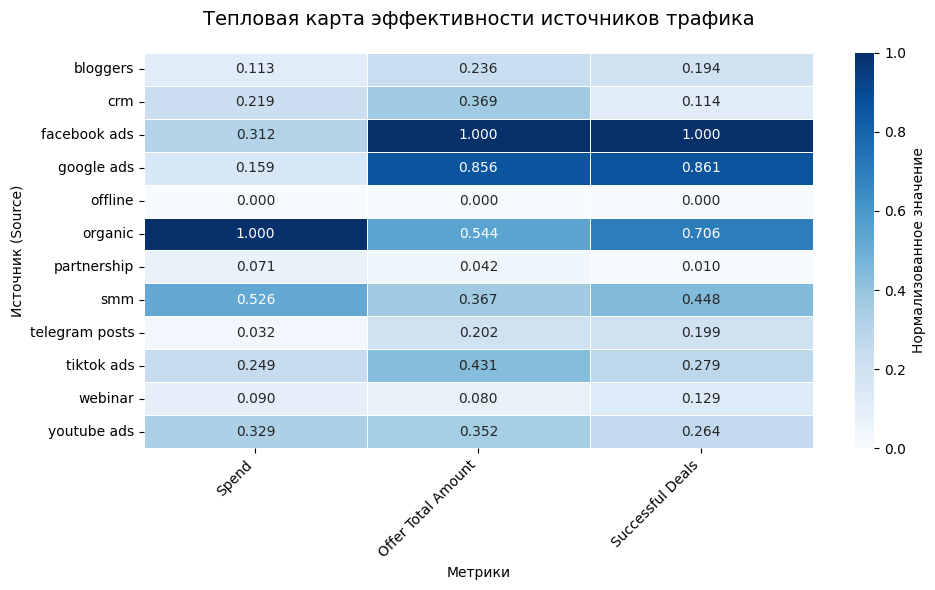

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# Убедимся, что 'Source' — индекс, если ещё не установлен
if 'Source' in heatmap_data_normalized.columns:
    heatmap_data_indexed = heatmap_data_normalized.set_index('Source')
else:
    heatmap_data_indexed = heatmap_data_normalized  # уже с индексом

# Выбираем числовые столбцы
data_for_heatmap = heatmap_data_indexed[['Spend', 'Offer Total Amount', 'Successful Deals']]

# 🔹 НЕ НУЖНО масштабировать снова — данные уже нормализованы!
# data_scaled = data_for_heatmap  # уже в диапазоне 0–1

# Построение тепловой карты
plt.figure(figsize=(10, 6))
sns.heatmap(
    data_for_heatmap,  # уже нормализовано, используем напрямую
    annot=heatmap_data_indexed[['Spend', 'Offer Total Amount', 'Successful Deals']].round(3),  # можно округлить
    fmt=".3f",
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Нормализованное значение'}
)

plt.title('Тепловая карта эффективности источников трафика', fontsize=14, pad=20)
plt.xlabel('Метрики')
plt.ylabel('Источник (Source)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Вывод:**
Тепловая карта показывает, показывает следующие ключевые моменты:

Facebook Ads и Google ads демонстрируют высокую корреляцию между всеми метриками, 31% и 11% затрат, 100%  и 86% доходов, и 100% и 86% успешных сделок соответственно. Это указывает на высокую эффективность этих каналов.

SMM и Tiktok Ads также показывают сильную корреляцию между метриками, что делает их эффективными каналами. SMM  52% затрат, 37% доходов и 45% успешных сделок, в то же время как Tiktok Ads имеет 25% затрат, 37% доходов и 45% успешных сделок.

Organic трафик выделяется высоким количеством затрат (100%), при этом обеспечивая 54% доходов и 70% успешных сделок, что указывает на  его важность как источника трафика, но необходимо пересмотреть расходы.

Таким образом, тепловая карта показывает высокую корреляцию между затратами и доходами для таких каналов, как  Facebook Ads, Google ads, SMM и Tiktok Ads, что подтверждает их эффективность. Каналы youtube ads и smm требуют дополнительного анализа и оптимизации.

## 5. Анализ эффективности работы отдела продаж
### 5.1. Оцените эффективность отдельных владельцев сделок и рекламных кампаний с точки зрения количества обработанных сделок, коэффициента конверсии и общей суммы продаж.
#### 5.1.1. Проанализируем эффективность отдельных владельцев сделок с точки зрения количества обработанных сделок, коэффициента конверсии и общей суммы продаж (статус Payment Done)
Создадим таблицу, включающую столбцы "Deal Owner Name", "Total Deals", "Successful Deals", "Offer Total Amount" и "Conversion Rate", а тажке посмотрим эти данные на графиках, что поможет достичь нам следующих целей:

Проаназировать количество обработанных сделок и понять, сколько сделок было обработано каждым владельцем, чтобы оценить их рабочую нагрузку и продуктивность.

Проаназировать количество успешных сделок (статус "Payment Done"), чтобы оценить, насколько эффективны владельцы в закрытии сделок.

Проаназировать общую сумму продаж - это общая сумма предложений, которые были успешно закрыты. Таким образом мы можем измерить финансовый вклад каждого владельца в общие продажи.

Проаназировать коэффициент конверсии, который показывает процент успешных сделок относительно общего числа обработанных сделок, что позволяет оценить эффективность работы владельца сделок.

In [56]:
# Рассчет количества уникальных обработанных сделок для каждого владельца сделки, исключая значения 'Unknown'
owner_deals = deals[deals['Deal Owner Name'] != 'Unknown'].groupby('Deal Owner Name', observed=True)['Id'].nunique().reset_index(name='Total Deals')

# Рассчет количества успешных сделок для каждого владельца сделки, исключая значения 'Unknown'
successful_owner_deals = deals[(deals['Deal Owner Name'] != 'Unknown') & (deals['Stage'] == 'Payment Done')].groupby('Deal Owner Name', observed=True)['Id'].nunique().reset_index(name='Successful Deals')

# Рассчет суммы оплат для каждого владельца сделки, исключая значения 'Unknown'
total_sales = deals[(deals['Deal Owner Name'] != 'Unknown') & (deals['Stage'] == 'Payment Done')].groupby('Deal Owner Name', observed=True)['Offer Total Amount'].sum().reset_index()

# Объединение данных
owner_performance = pd.merge(owner_deals, successful_owner_deals, on='Deal Owner Name', how='left')
owner_performance = pd.merge(owner_performance, total_sales, on='Deal Owner Name', how='left')

# Заполнение NaN значений и расчет коэффициента конверсии
owner_performance['Successful Deals'] = owner_performance['Successful Deals'].fillna(0)
owner_performance['Offer Total Amount'] = owner_performance['Offer Total Amount'].fillna(0)
owner_performance['Conversion Rate'] = owner_performance['Successful Deals'] / owner_performance['Total Deals'] * 100

# Сортировка данных по убыванию количества успешных сделок
owner_performance_sorted = owner_performance.sort_values(by='Successful Deals', ascending=False)

# Переименование столбцов для удобства
owner_performance_sorted.columns = ['Deal Owner Name', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']

# Форматирование значений в колонках
formatted_owner_performance_sorted = owner_performance_sorted[['Deal Owner Name', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']].style.format({
    'Successful Deals': '{:,.0f}',
    'Offer Total Amount': '{:,.0f}',
    'Conversion Rate': '{:.2f}'
}).hide(axis='index')

# Вывод таблицы без индекса
display(formatted_owner_performance_sorted)

Deal Owner Name,Total Deals,Successful Deals,Offer Total Amount,Conversion Rate
Charlie Davis,2952,145,"1,040,600",4.91
Ulysses Adams,2164,141,"1,010,400",6.52
Julia Nelson,2239,93,"729,201",4.15
Paula Underwood,1860,93,"693,000",5.00
Quincy Vincent,1877,64,"460,000",3.41
Oliver Taylor,158,50,"524,500",31.65
Nina Scott,1282,46,"325,900",3.59
Ben Hall,1345,46,"344,500",3.42
Victor Barnes,1225,43,"331,900",3.51
Kevin Parker,563,37,"340,900",6.57


**Краткий вывод по таблице:**

Лидеры по количеству сделок и их успешности: Charlie Davis, Ulysses Adams, Julia Nelson и Paula Underwood  показали высокие результаты как по общему количеству обработанных сделок, так и по числу успешных сделок, что свидетельствует об их высокой продуктивности и эффективности.

Высокий коэффициент конверсии: Oliver Taylor демонстрирует наивысший коэффициент конверсии (31.65%), что может свидетельствовать о его умении эффективно доводить сделки до успешного завершения, несмотря на небольшое общее количество сделок.

Суммарная выручка: Charlie Davis и Ulysses Adams внесли наибольший финансовый вклад, с общими суммами продаж 1,040,600 и 1,010,400 соответственно, что делает их ключевыми игроками в команде продаж.

Таким образом представленные данные могут помочь выявить лучших сотрудников и определить области для улучшения, а также более точно оценить вклад каждого владельца сделок в успех компании.

Для наглядного представления данных из таблицы эффективности владельцев сделок, 
предлагаю использовать следующие визуализации:

Гистограмма количества обработанных сделок по владельцам

Гистограмма количества успешных сделок по владельцам

Гистограмма суммы продаж по владельцам

График коэффициента конверсии по владельцам

Эти графики помогут наглядно представить основные показатели, что упростит анализ и выявление ключевых игроков и областей для улучшения.

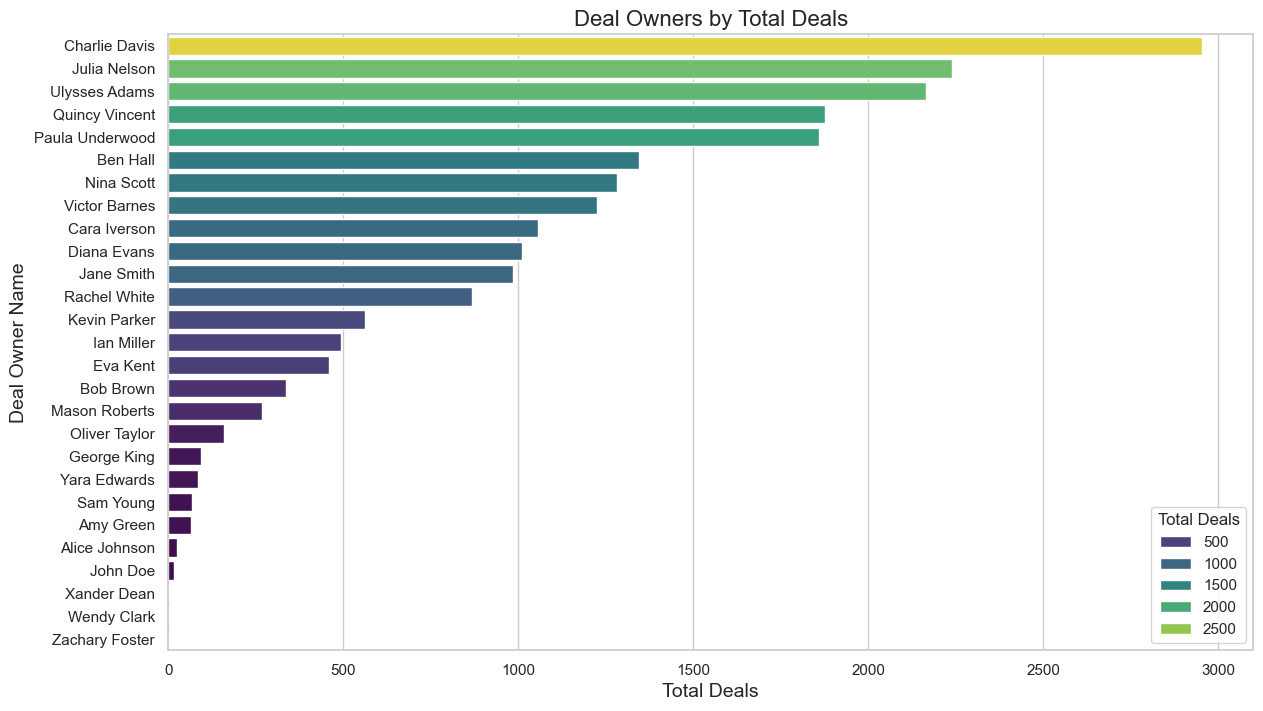

In [57]:
# Гистограмма количества обработанных сделок по владельцам

# Установка стиля для графика (добавим светлую сетку на светлом фоне)
sns.set(style="whitegrid")

# Преобразование типа данных в строковый и фильтрация данных: исключение "Unknown"
owner_performance_sorted['Deal Owner Name'] = owner_performance_sorted['Deal Owner Name'].astype(str)
filtered_data = owner_performance_sorted[owner_performance_sorted['Deal Owner Name'] != 'Unknown']

# # Преобразование типа данных в строковый и фильтрация данных: исключение "Unknown" (Преобразование типа данных в строковый - без этого шага фильтр не отрабатывал)
# filtered_data = owner_performance_sorted[owner_performance_sorted['Deal Owner Name'].astype(str) != 'Unknown']

# Сортировка данных по убыванию количества обработанных сделок
sorted_data = filtered_data.sort_values(by='Total Deals', ascending=False)

# Гистограмма количества обработанных сделок
plt.figure(figsize=(14, 8))
sns.barplot(x='Total Deals', y='Deal Owner Name', data=sorted_data, hue='Total Deals', dodge=False, palette='viridis')
plt.title('Deal Owners by Total Deals', fontsize=16)
plt.xlabel('Total Deals', fontsize=14)
plt.ylabel('Deal Owner Name', fontsize=14)
plt.show()

**ВЫВОД:** <График количества обработанных сделок по владельцам> показывает, что несколько владельцев сделок, таких как Charlie Davis, Ulysses Adams, Julia Nelson и Paula Underwood, значительно выделяются по количеству обработанных сделок, имея более 1500 сделок каждый. В то время как многие другие владельцы имеют гораздо меньшее количество сделок, что может указывать на значительные различия в рабочей нагрузке или эффективности среди сотрудников.

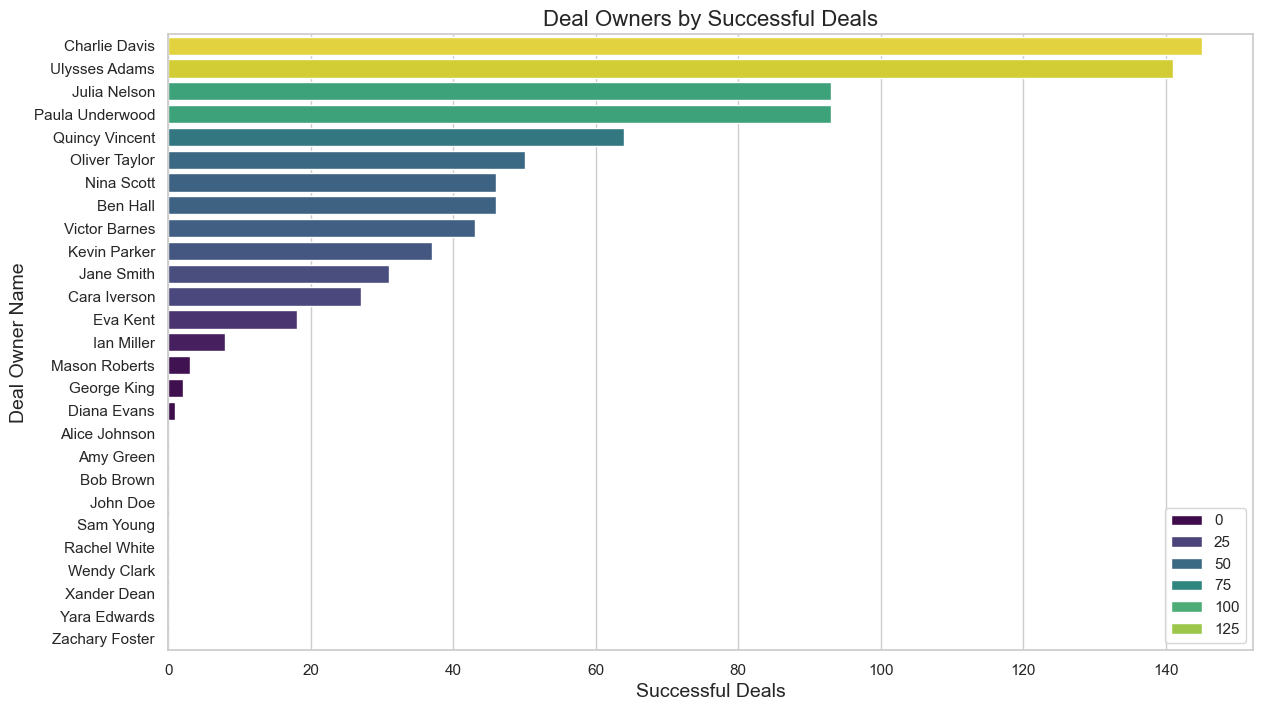

In [24]:
# Гистограмма количества успешных сделок по владельцам

# Установка стиля для графика (добавим светлую сетку на светлом фоне)
sns.set(style="whitegrid")

# Преобразование типа данных в строковый и фильтрация данных: исключение "Unknown" 
filtered_data = owner_performance_sorted[owner_performance_sorted['Deal Owner Name'].astype(str) != 'Unknown']

# Сортировка данных по убыванию количества успешных сделок
sorted_data = filtered_data.sort_values(by='Successful Deals', ascending=False)

# # Проверка данных перед построением графика
# print(sorted_data[['Deal Owner Name', 'Successful Deals']]) - данные сортируются, и на графике будут отсортированы корректно

# Гистограмма количества успешных сделок
plt.figure(figsize=(14, 8))
sns.barplot(x='Successful Deals', y='Deal Owner Name', data=sorted_data, hue='Successful Deals', dodge=False, palette='viridis')
plt.title('Deal Owners by Successful Deals', fontsize=16)
plt.xlabel('Successful Deals', fontsize=14)
plt.ylabel('Deal Owner Name', fontsize=14)
plt.legend(loc='lower right')
plt.show()

**ВЫВОД:** <График количества успешных сделок по владельцам> показывает распределение успешных сделок среди различных владельцев сделок. Charlie Davis и Ulysses Adams лидируют с самым большим количеством успешных сделок, что указывает на их высокую эффективность. Julia Nelson  и Paula Underwood  также демонстрируют хорошие результаты, занимая третье и четвертое места соответственно. Средние показатели у Quincy Vincent, Oliver Taylor, Nina Scott и Ben Hall. Такие менееджеры,  как George King, Diana Evans, Yara Edwards и другие, имеют меньше успешных сделок, что может свидетельствовать о необходимости улучшения их методов работы.

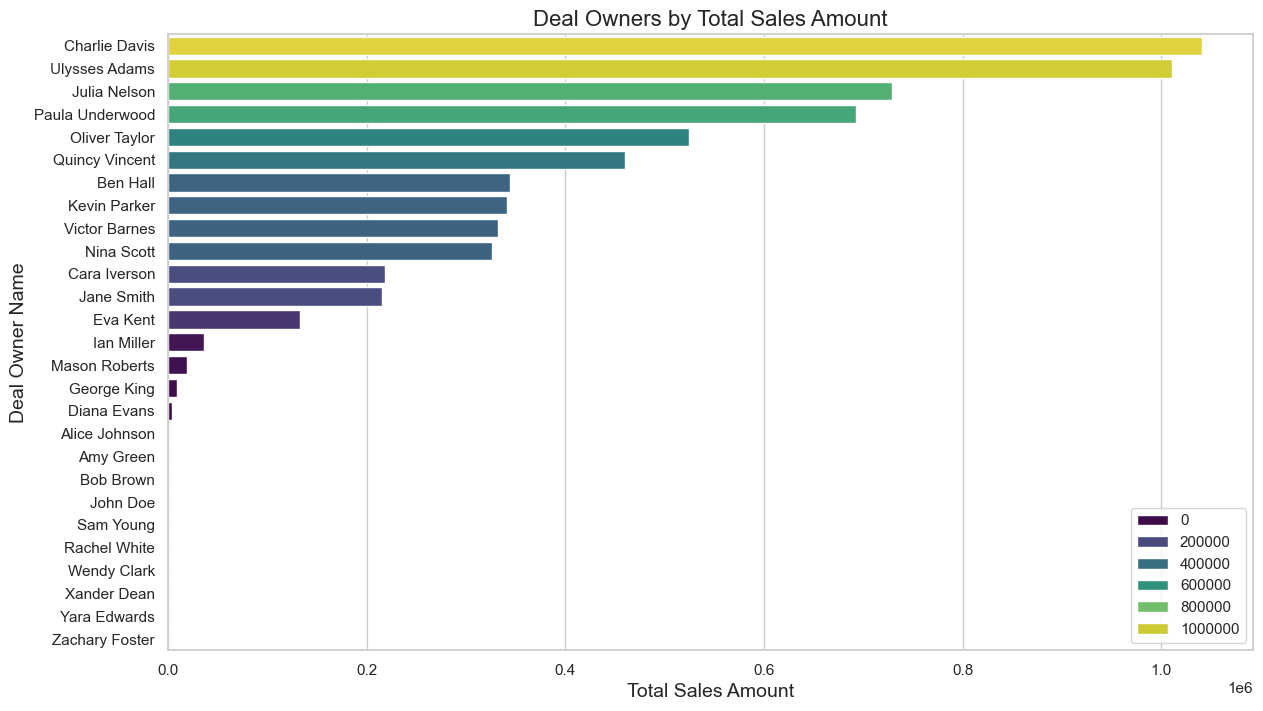

In [63]:
# Гистограмма суммы продаж по владельцам

# Установка стиля для графика (добавим светлую сетку на светлом фоне)
sns.set(style="whitegrid")

# Преобразование типа данных в строковый (для построения графика и фильтрации)
owner_performance_sorted['Deal Owner Name'] = owner_performance_sorted['Deal Owner Name'].astype(str)

# Преобразование столбца Offer Total Amount в стандартный тип int64 (для построения графика и фильтрации)
owner_performance_sorted['Offer Total Amount'] = owner_performance_sorted['Offer Total Amount'].astype('int64')

# Фильтрация данных: исключение "Unknown"
filtered_data = owner_performance_sorted[owner_performance_sorted['Deal Owner Name'] != 'Unknown']

# Сортировка данных по убыванию суммы продаж
sorted_data = filtered_data.sort_values(by='Offer Total Amount', ascending=False)

# Гистограмма суммы продаж
plt.figure(figsize=(14, 8))
sns.barplot(x='Offer Total Amount', y='Deal Owner Name', data=sorted_data, hue='Offer Total Amount', dodge=False, palette='viridis')
plt.title('Deal Owners by Total Sales Amount', fontsize=16)
plt.xlabel('Total Sales Amount', fontsize=14)
plt.ylabel('Deal Owner Name', fontsize=14)
plt.legend(loc='lower right')
plt.show()

**ВЫВОД:** <График суммы продаж по владельцам> показывает, что лидеры по общему количеству сделок (Charlie Davis, Ulysses Adams, Julia Nelson и Paula Underwood) также имеют наибольшие суммы продаж, подтверждая их эффективность. При этом Oliver Taylor имеет высокую сумму продаж несмотря на меньшее количество сделок, что свидетельствует о его способности заключать более ценные сделки. Напротив, владельцы сделок с наименьшими суммами продаж и низким количеством успешных сделок требуют улучшения показателей для повышения общей эффективности отдела продаж.

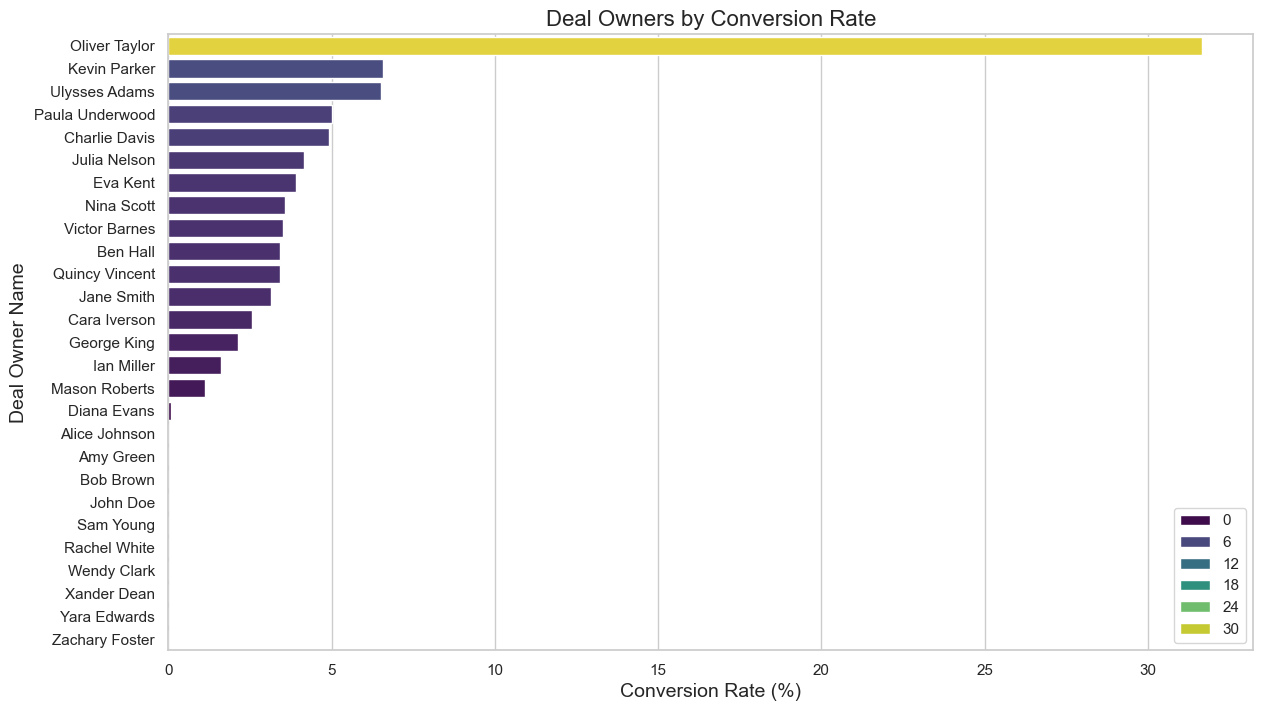

In [64]:
# Гистограмма коэффициента конверсии по владельцам

# Установка стиля для графика (добавим светлую сетку на светлом фоне)
sns.set(style="whitegrid")

# Преобразование типа данных в строковый и фильтрация данных: исключение "Unknown"
filtered_data = owner_performance_sorted[owner_performance_sorted['Deal Owner Name'].astype(str) != 'Unknown']

# Сортировка данных по убыванию коэффициента конверсии
sorted_data = filtered_data.sort_values(by='Conversion Rate', ascending=False)

# Гистограмма коэффициента конверсии
plt.figure(figsize=(14, 8))
sns.barplot(x='Conversion Rate', y='Deal Owner Name', data=sorted_data, hue='Conversion Rate', dodge=False, palette='viridis')
plt.title('Deal Owners by Conversion Rate', fontsize=16)
plt.xlabel('Conversion Rate (%)', fontsize=14)
plt.ylabel('Deal Owner Name', fontsize=14)
plt.legend(loc='lower right')
plt.show()

**ВЫВОД:** <График коэффициента конверсии по владельцам> показывает, что Oliver Taylor значительно превосходит всех остальных с коэффициентом конверсии около 30%, что свидетельствует о его высокой эффективности в завершении сделок. В то время как Кевин Паркер и Улисс Адамс  также показывают хорошие результаты с коэффициентами конверсии около 7%, другие владельцы сделок демонстрируют более скромные результаты, в диапазоне от 0% до 5%. Этот анализ помогает выявить наиболее успешных сотрудников и направить усилия на повышение эффективности остальных.

#### 5.1.2. 
Проанализируем эффективность отдельных рекламных кампаний с точки зрения количества обработанных сделок, коэффициента конверсии и общей суммы продаж (статус Payment Done)
Создадим таблицу, включающую столбцы "Campaign", "Total Deals", "Successful Deals", "Offer Total Amount" и "Conversion Rate", Таким обзазом мы сможем увидеть количество сделок, успешные сделки, сумму предложений и коэффициент конверсии для каждой кампании.

In [65]:
# Рассчет количества уникальных обработанных сделок для каждой кампании
campaign_deals = deals[deals['Campaign'] != 'Unknown'].groupby('Campaign', observed=True)['Id'].nunique().reset_index(name='Total Deals')

# Рассчет количества успешных сделок для каждой кампании
successful_campaign_deals = deals[(deals['Stage'] == 'Payment Done') & (deals['Campaign'] != 'Unknown')].groupby('Campaign', observed=True)['Id'].nunique().reset_index(name='Successful Deals')

# Рассчет суммы оплат для каждой кампании
total_sales_campaign = deals[(deals['Stage'] == 'Payment Done') & (deals['Campaign'] != 'Unknown')].groupby('Campaign', observed=True)['Offer Total Amount'].sum().reset_index()

# Объединение данных
campaign_performance = pd.merge(campaign_deals, successful_campaign_deals, on='Campaign', how='left')
campaign_performance = pd.merge(campaign_performance, total_sales_campaign, on='Campaign', how='left')

# Заполнение NaN значений и расчет коэффициента конверсии
campaign_performance['Successful Deals'] = campaign_performance['Successful Deals'].fillna(0)
campaign_performance['Offer Total Amount'] = campaign_performance['Offer Total Amount'].fillna(0)
campaign_performance['Conversion Rate'] = campaign_performance['Successful Deals'] / campaign_performance['Total Deals'] * 100

# Сортировка данных по убыванию количества успешных сделок
campaign_performance_sorted = campaign_performance.sort_values(by='Successful Deals', ascending=False)

# Переименование столбцов для удобства
campaign_performance_sorted.columns = ['Campaign', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']

# Форматирование значений в колонках
formatted_campaign_performance_sorted = campaign_performance_sorted[['Campaign', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']].style.format({
    'Successful Deals': '{:,.0f}',
    'Offer Total Amount': '{:,.0f}',
    'Conversion Rate': '{:.2f}'
}).hide(axis='index')

# Вывод таблицы без индекса
display(formatted_campaign_performance_sorted)

Campaign,Total Deals,Successful Deals,Offer Total Amount,Conversion Rate
performancemax_digitalmarkt_ru_DE,2652,112,"872,400",4.22
youtube_shorts_DE,1635,53,"415,500",3.24
02.07.23wide_DE,974,52,"396,900",5.34
12.07.2023wide_DE,1575,48,"336,400",3.05
04.07.23recentlymoved_DE,750,31,"201,100",4.13
03.07.23women,612,31,"266,900",5.07
Dis_DE,581,30,"232,500",5.16
07.07.23LAL_DE,542,28,"243,000",5.17
12.09.23interests_Uxui_DE,531,27,"240,000",5.08
24.09.23retargeting_DE,479,17,"145,900",3.55


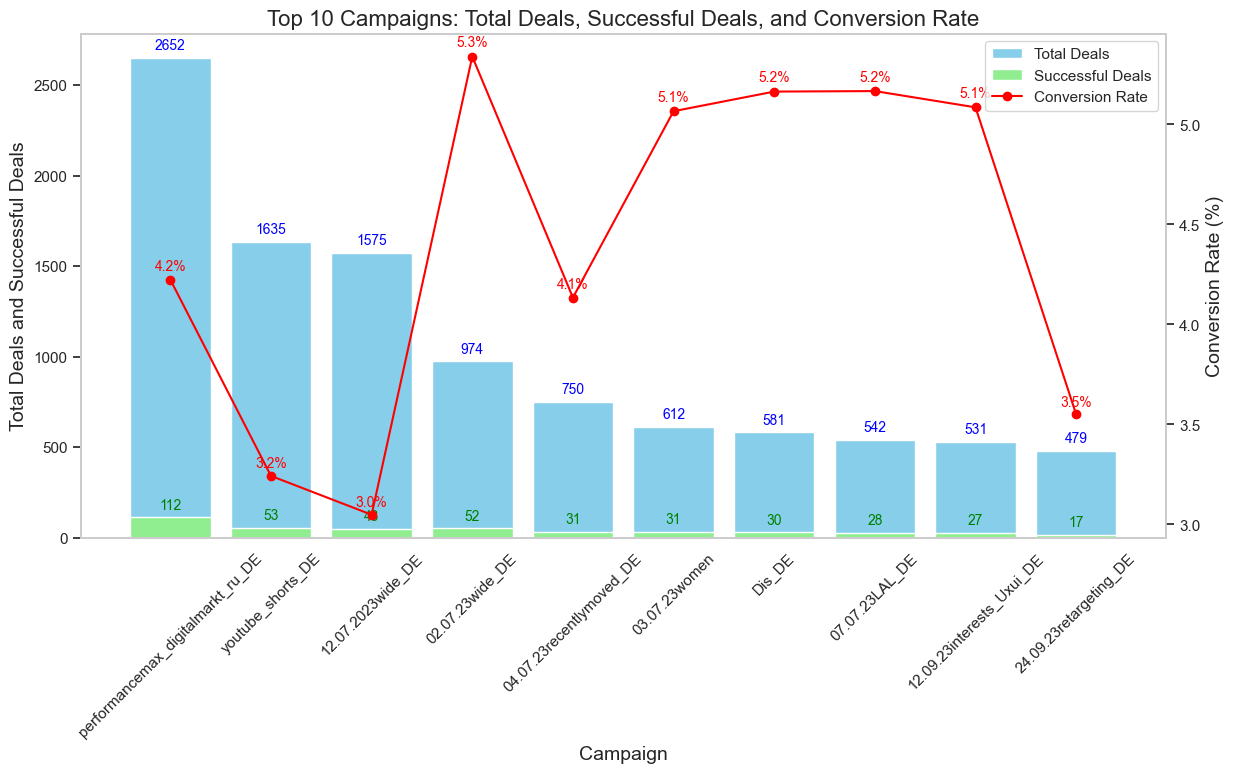

In [66]:
# Подготовка данных: сортировка кампаний по убыванию сделок
top_10_campaigns = campaign_performance_sorted.sort_values(
    by='Total Deals', ascending=False
).head(10)

# Создание графика
fig, ax1 = plt.subplots(figsize=(14, 8))

# Количество сделок (столбчатая диаграмма)
ax1.set_title('Top 10 Campaigns: Total Deals, Successful Deals, and Conversion Rate', fontsize=16)
ax1.set_xlabel('Campaign', fontsize=14)
ax1.set_ylabel('Total Deals and Successful Deals', fontsize=14)

bars1 = ax1.bar(
    top_10_campaigns['Campaign'], 
    top_10_campaigns['Total Deals'], 
    color='skyblue', 
    label='Total Deals'
)
bars2 = ax1.bar(
    top_10_campaigns['Campaign'], 
    top_10_campaigns['Successful Deals'], 
    color='lightgreen', 
    label='Successful Deals'
)

ax1.tick_params(axis='x', rotation=45)
ax1.grid(False)  # убираем гриды с первой оси

# Коэффициент конверсии (линейный график)
ax2 = ax1.twinx()
ax2.set_ylabel('Conversion Rate (%)', fontsize=14)

line, = ax2.plot(
    top_10_campaigns['Campaign'], 
    top_10_campaigns['Conversion Rate'], 
    color='red', marker='o', label='Conversion Rate'
)

ax2.grid(False)  # убираем гриды со второй оси

# Легенда
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

# Подписи для Total Deals
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 30, int(yval),
             ha='center', va='bottom', fontsize=10, color='blue')

# Подписи для Successful Deals
for bar in bars2:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 30, int(yval),
             ha='center', va='bottom', fontsize=10, color='green')

# Подписи для Conversion Rate (чуть выше точек)
for i, (x, y) in enumerate(zip(top_10_campaigns['Campaign'], top_10_campaigns['Conversion Rate'])):
    ax2.text(i, y + (y * 0.005 + 0.01), f"{y:.1f}%",
             ha='center', va='bottom', fontsize=10, color='red')

plt.subplots_adjust(bottom=0.25)
plt.show()

**ВЫВОД:** Анализ эффективности рекламных кампаний показывает, что кампания "performancemax_digitalmarkt_ru_DE" имеет наибольшее количество сделок (2652) и высокий коэффициент конверсии (4.2%). Кампании "youtube_shorts_DE" и "12.07.23wide_DE" также демонстрируют значительное количество успешных сделок, несмотря на меньшее общее количество сделок. Отдельно следует отметить кампанию "12.07.23wide_DE" , которая показала наивысшую конверсию (5,3%). Этот удачный показатель нуждается в детальном анализе с целью дельнейшего масштабирования. В то же время кампания "24.09.23retargeting_DE" имеет самую низкую конверсию (3.5%) и наименьшее количество успешных сделок (17), что указывает на необходимость пересмотра ее эффективности и возможных улучшений.

## 6. Анализ платежей и продуктов
   
### 6.1. Изучите распределение типов оплаты и их влияние на успешность сделок.
Создадим диаграмму с общим количеством сделок, количеством успешных сделок и линией коэффициента конверсии для каждого типа оплаты, чтобы проанализировать эти данные.

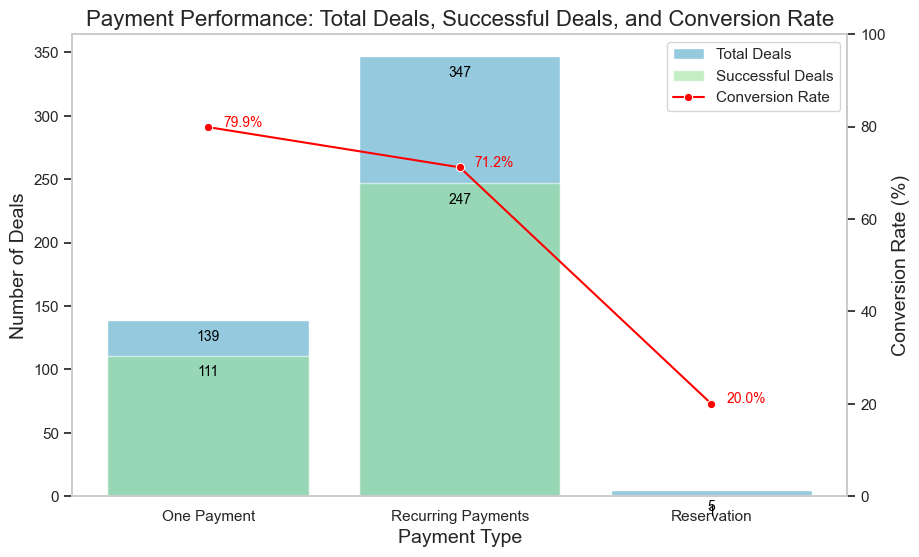

In [67]:
# Преобразование типа данных в строковый и фильтрация данных: исключение "Unknown"
filtered_deals = deals[deals['Payment Type'].astype(str) != 'Unknown']

# Рассчет количества уникальных обработанных сделок для каждого типа оплаты
total_payments = filtered_deals.groupby('Payment Type', observed=True)['Id'].nunique().reset_index(name='Total Deals')

# Рассчет количества успешных сделок для каждого типа оплаты
successful_payments = filtered_deals[filtered_deals['Stage'] == 'Payment Done'].groupby('Payment Type', observed=True)['Id'].nunique().reset_index(name='Successful Deals')

# Объединение данных для расчета коэффициента конверсии
payment_performance = pd.merge(total_payments, successful_payments, on='Payment Type', how='left')
payment_performance['Successful Deals'] = payment_performance['Successful Deals'].fillna(0)
payment_performance['Conversion Rate'] = (payment_performance['Successful Deals'] / payment_performance['Total Deals'] * 100).round(1)

# Визуализация
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x='Payment Type', y='Total Deals', data=payment_performance, color='skyblue', label='Total Deals', hue_order=None)
sns.barplot(x='Payment Type', y='Successful Deals', data=payment_performance, color='lightgreen', label='Successful Deals', alpha=0.6, hue_order=None)

# Создание второй оси
ax2 = ax1.twinx()
sns.lineplot(x='Payment Type', y='Conversion Rate', data=payment_performance, color='red', marker='o', label='Conversion Rate', ax=ax2, legend=False)

# Настройка меток данных
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height)}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='center', fontsize=10, color='black', xytext=(0, -12), 
                 textcoords='offset points')

for line in ax2.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax2.annotate(f'{y:.1f}%', (x, y + 1), ha='center', va='center', fontsize=10, color='red', xytext=(25, 0), 
                     textcoords='offset points')

# Настройка заголовков и осей
ax1.set_title('Payment Performance: Total Deals, Successful Deals, and Conversion Rate', fontsize=16)
ax1.set_xlabel('Payment Type', fontsize=14)
ax1.set_ylabel('Number of Deals', fontsize=14)
ax2.set_ylabel('Conversion Rate (%)', fontsize=14)
ax2.set_ylim(0, 100)  # Устанавливаем ось Y для конверсии от 0 до 100

# Настройка общей легенды
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1[:2] + [handles2[0]]
labels = ['Total Deals', 'Successful Deals', 'Conversion Rate']
ax1.legend(handles=handles, labels=labels, loc='upper right')

# Удаление линий разметки
ax1.grid(False)
ax2.grid(False)

plt.show()

**ВЫВОД:** наиболее эффективным типом оплаты являются "Recurring Payments" с общим числом сделок 347, из которых 247 завершились успешно, что составляет коэффициент конверсии 71.2%. Вторым по эффективности типом оплаты является "One Payment" с общим числом сделок 139 и успешными 111 сделками, что дает коэффициент конверсии 79.9%. Наименее эффективным типом оплаты является "Reservation" с всего 5 сделками и коэффициентом конверсии 20.0%.

Выведем таблицу, показывающую рассчет метрик по типам обучения:

количество сделок для каждого типа обучения
количество успешных сделок для каждого типа обучения
сумма оплат для успешных сделок по каждому типу обучения (со статусом "Payment Done")
коэффициент конверсии для каждого типа обучения

In [68]:
# Преобразование типа данных в строковый и фильтрация данных
filtered_deals = deals[deals['Education Type'].astype(str).isin(['Morning', 'Evening'])]

# Рассчет количества уникальных обработанных сделок для каждого типа обучения
education_deals = filtered_deals.groupby('Education Type', observed=True)['Id'].nunique().reset_index(name='Total Deals')

# Рассчет количества успешных сделок для каждого типа обучения
successful_education_deals = filtered_deals[filtered_deals['Stage'] == 'Payment Done'].groupby('Education Type', observed=True)['Id'].nunique().reset_index(name='Successful Deals')

# Рассчет суммы оплат для каждого типа обучения
total_sales_education = filtered_deals[filtered_deals['Stage'] == 'Payment Done'].groupby('Education Type', observed=True)['Offer Total Amount'].sum().reset_index()

# Объединение данных
education_performance = pd.merge(education_deals, successful_education_deals, on='Education Type', how='left')
education_performance = pd.merge(education_performance, total_sales_education, on='Education Type', how='left')

# Заполнение NaN значений и расчет коэффициента конверсии
education_performance['Successful Deals'] = education_performance['Successful Deals'].fillna(0)
education_performance['Offer Total Amount'] = education_performance['Offer Total Amount'].fillna(0)
education_performance['Conversion Rate'] = education_performance['Successful Deals'] / education_performance['Total Deals'] * 100

# Сортировка данных по убыванию количества успешных сделок
education_performance_sorted = education_performance.sort_values(by='Successful Deals', ascending=False)

# Переименование столбцов для удобства
education_performance_sorted.columns = ['Education Type', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']

# Форматирование значений в колонках и вывод таблицы
formatted_education_performance_sorted = education_performance_sorted[['Education Type', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']].style.format({
    'Successful Deals': '{:,.0f}',
    'Offer Total Amount': '{:,.0f}',
    'Conversion Rate': '{:.2f}'
}).hide(axis='index')

# Вывод таблицы
display(formatted_education_performance_sorted)

Education Type,Total Deals,Successful Deals,Offer Total Amount,Conversion Rate
Morning,2875,655,"5,566,500",22.78
Evening,401,170,"622,300",42.39


ВЫВОД: На основе данных таблицы мы можем видеть, что тип обучения "Morning" привлек больше всего сделок (2875) и обеспечил самую высокую сумму продаж (5,566,500), однако его коэффициент конверсии составляет 22.78%. С другой стороны, тип обучения "Evening" показал меньшую общую активность с 401 сделками и суммой продаж 622,300, но при этом продемонстрировал значительно более высокий коэффициент конверсии — 42,39%. Это указывает на то, что вечерние занятия, хотя и менее популярны, имеют более высокую эффективность в преобразовании лидов в успешные сделки.

Выведем таблицу, показывающую рассчет метрик по продуктам с учетом типов обучения:

количество сделок для каждого продукта
количество успешных сделок для каждого продукта (со статусом "Payment Done")
сумма оплат для успешных сделок по каждому продукту
коэффициент конверсии для каждого продукта

In [69]:
# Рассчет количества уникальных обработанных сделок для каждого продукта и типа обучения
product_education_deals = deals.groupby(['Product', 'Education Type'], observed=True)['Id'].nunique().reset_index(name='Total Deals')

# Рассчет количества успешных сделок для каждого продукта и типа обучения
successful_product_education_deals = deals[deals['Stage'] == 'Payment Done'].groupby(['Product', 'Education Type'], observed=True)['Id'].nunique().reset_index(name='Successful Deals')

# Рассчет суммы оплат для каждого продукта и типа обучения
total_sales_product_education = deals[deals['Stage'] == 'Payment Done'].groupby(['Product', 'Education Type'], observed=True)['Offer Total Amount'].sum().reset_index()

# Объединение данных
product_education_performance = pd.merge(product_education_deals, successful_product_education_deals, on=['Product', 'Education Type'], how='left')
product_education_performance = pd.merge(product_education_performance, total_sales_product_education, on=['Product', 'Education Type'], how='left')

# Заполнение NaN значений и расчет коэффициента конверсии
product_education_performance['Successful Deals'] = product_education_performance['Successful Deals'].fillna(0)
product_education_performance['Offer Total Amount'] = product_education_performance['Offer Total Amount'].fillna(0)
product_education_performance['Conversion Rate'] = product_education_performance['Successful Deals'] / product_education_performance['Total Deals'] * 100

# Сортировка данных по убыванию количества успешных сделок
product_education_performance_sorted = product_education_performance.sort_values(by='Successful Deals', ascending=False)

# Переименование столбцов для удобства
product_education_performance_sorted.columns = ['Product', 'Education Type', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']

# Исключение пустых значений и значений "Unknown" и "#REF!"
product_education_performance_sorted = product_education_performance_sorted[
    product_education_performance_sorted['Product'].notnull() &
    (product_education_performance_sorted['Product'] != 'Unknown') &
    product_education_performance_sorted['Education Type'].notnull() &
    (product_education_performance_sorted['Education Type'] != '#REF!') &
    (product_education_performance_sorted['Education Type'] != 'Unknown')
]

# Форматирование значений в колонках
formatted_product_education_performance_sorted = product_education_performance_sorted[['Product', 'Education Type', 'Total Deals', 'Successful Deals', 'Offer Total Amount', 'Conversion Rate']].style.format({
    'Total Deals': '{:,.0f}',
    'Successful Deals': '{:,.0f}',
    'Offer Total Amount': '{:,.0f}',
    'Conversion Rate': '{:.2f}'
}).hide(axis='index')

# Вывод таблицы без индекса
display(formatted_product_education_performance_sorted)

Product,Education Type,Total Deals,Successful Deals,Offer Total Amount,Conversion Rate
Digital Marketing,Morning,"1,524",350,"3,393,500",22.97
UX/UI Design,Morning,801,169,"1,594,900",21.10
Web Developer,Morning,541,136,"578,100",25.14
Digital Marketing,Evening,248,112,"404,800",45.16
UX/UI Design,Evening,152,58,"217,500",38.16
Web Developer,Evening,1,0,0,0.00


ВЫВОД:

Утренние курсы привлекают больше всего сделок для всех продуктов, при этом курсы по Digital Marketing наиболее популярны и успешны, они имеют 1524 сделки, из которых 350 были успешными, что привело к общей сумме продаж в 3,393,500 и коэффициенту конверсии 22.97%.
Вечерние курсы по Digital Marketing также показывают высокий коэффициент конверсии (45.16%) при 248 сделках и 112 успешных сделках.
UX/UI Design и Web Developer курсы также популярны в утренние часы, с 801 и 541 сделками соответственно, и успешными сделками в 169 и 136.
Вечерние курсы по UX/UI Design имеют высокий коэффициент конверсии (38.16%) с 152 сделками и 58 успешными сделками.

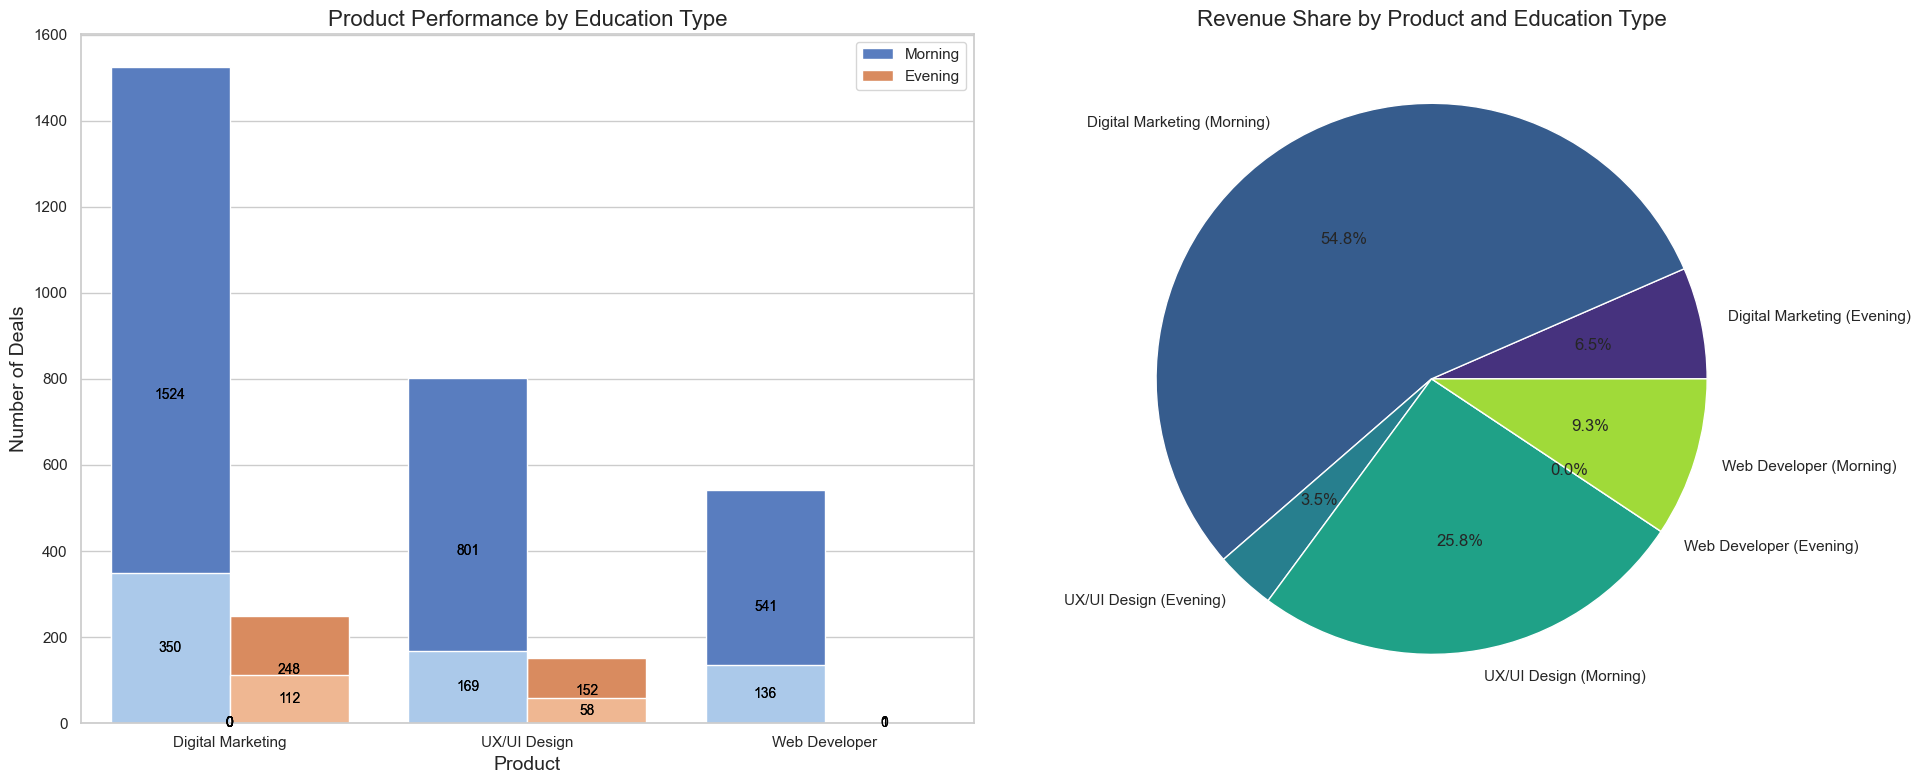

In [70]:
# Преобразование категориальных полей в строки и фильтрация данных
product_education_performance_sorted['Product'] = product_education_performance_sorted['Product'].astype(str)
product_education_performance_sorted['Education Type'] = product_education_performance_sorted['Education Type'].astype(str)

filtered_data = product_education_performance_sorted[
    product_education_performance_sorted['Product'].notnull() &
    (product_education_performance_sorted['Product'] != 'Unknown') &
    product_education_performance_sorted['Education Type'].notnull() &
    (product_education_performance_sorted['Education Type'] != '#REF!') &
    (product_education_performance_sorted['Education Type'] != 'Unknown')
]

# Установка стиля для графика
sns.set(style="whitegrid")

# Создание фигуры и осей
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Гистограммы общего количества сделок и успешных сделок
barplot1 = sns.barplot(x='Product', y='Total Deals', hue='Education Type', data=filtered_data, ax=ax1, palette='muted', dodge=True)
barplot2 = sns.barplot(x='Product', y='Successful Deals', hue='Education Type', data=filtered_data, ax=ax1, palette='pastel', dodge=True)

# Функция для добавления меток данных на столбцы
def add_labels(plot):
    for bar in plot.patches:
        plot.annotate(format(bar.get_height(), '.0f'),
                      (bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
                      ha='center', va='center', size=10, color='black')

# Добавление меток данных
add_labels(barplot1)
add_labels(barplot2)

# Настройка легенды и заголовков
ax1.set_title('Product Performance by Education Type', fontsize=16)
ax1.set_xlabel('Product', fontsize=14)
ax1.set_ylabel('Number of Deals', fontsize=14)

# Настройка общей легенды
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:len(handles)//2], labels[:len(labels)//2], loc='upper right')

# Пай-чарт для долей в деньгах с учетом типа обучения
pie_data = filtered_data.groupby(['Product', 'Education Type'])['Offer Total Amount'].sum()
ax2.pie(pie_data, labels=[f'{prod} ({edu})' for prod, edu in pie_data.index], autopct='%1.1f%%', colors=sns.color_palette('viridis', len(pie_data)))
ax2.set_title('Revenue Share by Product and Education Type', fontsize=16)

plt.tight_layout()
plt.show()

**ВЫВОДЫ:**
- <Гистограмма> показывает, что утренние курсы по Digital Marketing и UX/UI Design имеют наибольшее количество сделок, причем Digital Marketing лидирует с большим отрывом. Вечерние курсы также показывают хорошие результаты, особенно для Digital Marketing. В то же время, курс Web Developer имеет значительно меньше сделок, особенно в вечернее время.

- <Пай-чарт> демонстрирует, что большая часть дохода (54.8%) генерируется утренними курсами по Digital Marketing. Курсы по UX/UI Design (утро) составляют 25.8% дохода, а вечерние курсы значительно уступают утренним по всем направлениям. Курсы Web Developer имеют минимальный вклад в доход, особенно вечерние курсы.

## Общий вывод: 
#### Анализ эффективности отделов продаж:
- Количество обработанных сделок: Наибольшее количество сделок обработали Charlie Davis, Ulysses Adams, Paula Underwood и Julia Nelson, что указывает на их высокую активность. -->
- Количество успешных сделок: Charlie Davis, Ulysses Adams, Julia Nelson и Paula Underwood также лидируют по числу успешных сделок, что свидетельствует об их высокой эффективности.
- Сумма продаж: Самые высокие суммы продаж достигнуты Charlie Davis, Ulysses Adams и Julia Nelson.
Коэффициент конверсии: Oliver Taylor показал наивысший коэффициент конверсии (31.61%), что указывает на его способность превращать сделки в успешные с максимальной вероятностью.
#### Анализ эффективности рекламных кампаний:
- Количество обработанных сделок: Кампании 'performancemax_digitalmarkt_ru_DE', 'youtube_shorts_DE',  "12.07.23wide_DE" и "03.07.23women" показали наибольшее количество сделок.
- Количество успешных сделок: Наибольшее количество успешных сделок показали кампании 'performancemax_digitalmarkt_ru_DE', 'youtube_shorts_DE' и '12.07.23wide_DE'.
- Коэффициент конверсии: Кампании  "02.07.23wide_DE", "03.07.23women"  и 'Dis_DE', 07.07.23LAL_DE, 12.09.23interests_Uxui_DE  показали самые высокие коэффициенты конверсии (более 5% ).
- В то же время кампания "24.09.23retargeting_DE" имеет самую низкую конверсию (3.3%) и наименьшее количество успешных сделок (17), что указывает на необходимость пересмотра ее эффективности и возможных улучшений.
#### Анализ платежей:
- Типы оплат: Повторяющиеся платежи (Recurring Payments) являются наиболее популярным и успешным методом оплаты, с наибольшим количеством сделок и высоким коэффициентом конверсии (73.6%).
- Единоразовые платежи (One Payment): также показывают высокий коэффициент конверсии (79.7%), но с меньшим общим числом сделок.
- Бронирование (Reservation): показало самый низкий коэффициент конверсии (20.0%) и количество сделок.
#### Анализ типов обучения:
- Утренние и вечерние курсы: Утренние курсы более популярны (2383 сделок), но вечерние курсы имеют более высокий коэффициент конверсии (46.06%).
- Успешность: Вечерние курсы также показали высокий уровень успешности сделок.
#### Анализ продуктов и типов обучения:
- Digital Marketing: В утренние часы данный продукт имеет наибольшее количество сделок и успешных сделок.
- UX/UI Design и Web Developer: также популярны, особенно в утренние часы, но вечерние курсы показали высокий коэффициент конверсии для всех продуктов.

#### Общие рекомендации:
Эффективность отделов продаж и рекламных кампаний можно повысить за счет увеличения числа повторяющихся платежей и оптимизации расписания курсов. Важно учитывать высокие коэффициенты конверсии вечерних курсов и кампаний, таких как 'youtube_shorts_DE'. Рекомендовано продолжать акцент на цифровом маркетинге и развивать курсы по UX/UI дизайну и веб-разработке, особенно в вечернее время.

Этот анализ направлен на лучшее понимание динамики продаж, эффективности рекламных кампаний и предпочтений клиентов в отношении типов обучения и способов оплаты, что позволит компании принимать более обоснованные решения и улучшать стратегию продаж и маркетинга. ​

## ПРОДУКТОВАЯ АНАЛИТИКА 

**Найти точку роста бизнеса и сформулировать гипотезу улучшение бизнес процесса для роста метрик и опишите их механику тестирования с учетом того что тест не должен занимать больше 2-х недель.**

#### 1. Посчитать юнит-экономику по продуктам.

#### 2. Из юнит-экономики определить точки роста бизнеса.

#### 3. Понять дерево метрик для бизнеса.

#### 4. Понять на какую метрику продукта они будут воздействовать и сформировать гипотезы.

#### 5. Описать метод проверки гипотез с формулированием условия проведения гипотезы.

### 1. Посчитать юнит-экономику по продуктам (расчет метрик).
- **UA (Users)** - количество лидов (юнитов масштабирования)
- **B (Bayers)** - количество клиентов
- **C1 (Conversion Rate)** = B / UA = конверсия
- **AC (Marketing Budget)** - маркетинговый бюджет
- **CPA (Cost Per Acquisition)** = AC / UA = стоимость привлечения одного UA
- **CAC (Customer Acquisition Cost)** = AC / B = стоимость привлечения одного B
- **Gross Revenue (Total Sales)** - выручка общая
- **AOV (Average Order Value)** = Gross Revenue / B = средний чек
- **APC (Average Purchases per Customer)** - среднее число сделок на одного B
- **CLTV (Customer Lifetime Value)** = AOV × APC = средняя валовая прибыль на одного В (упростила формулу потому что нет данных для расчета GOGS и 1sGOGS)
- **LTV (Lifetime Value)** = Gross Revenue / UA = средняя валовая прибыль на одного UA
- **CM (Contribution Margin)** = (CLTV – CAC) × B = маржинальная прибыль
- **Total Deals (Total successful of deals)** - количество успешных сделок

In [71]:
import pandas as pd
# Установка стилей отображения
pd.set_option('display.float_format', '{:,.2f}'.format)

# UA (Users) - количество лидов (юнитов масштабирования)
users = deals.groupby(['Product', 'Education Type'], observed=True)['Id'].nunique().rename('UA')

# B (Bayers) - количество клиентов
bayers = deals[deals['Stage'] == 'Payment Done'].groupby(['Product', 'Education Type'], observed=True)['Id'].nunique().rename('Bayers')

# Total Deals (Total successful deals) - количество успешных сделок
total_deals = deals[deals['Stage'] == 'Payment Done'].groupby(['Product', 'Education Type'], observed=True)['Id'].count().rename('Total Deals')

# Gross Revenue (Total Sales) - выручка общая
gross_revenue = deals[deals['Stage'] == 'Payment Done'].groupby(['Product', 'Education Type'], observed=True)['Offer Total Amount'].sum().rename('Gross Revenue')

# Объединение данных в один DataFrame
merged_df = users.to_frame().join([bayers, total_deals, gross_revenue], how='left').reset_index()

# AC (Marketing Budget) - общий маркетинговый бюджет для всех продуктов
total_ac = spend['Spend'].sum()

# Расчет метрик
merged_df['C1'] = merged_df['Bayers'] / merged_df['UA']
merged_df['AC'] = total_ac
merged_df['CPA'] = merged_df['AC'] / merged_df['UA']
merged_df['CAC'] = merged_df['AC'] / merged_df['Bayers']
merged_df['AOV'] = merged_df['Gross Revenue'] / merged_df['Bayers']
merged_df['APC'] = merged_df['Total Deals'] / merged_df['Bayers']
merged_df['CLTV'] = merged_df['AOV'] * merged_df['APC']
merged_df['LTV'] = merged_df['Gross Revenue'] / merged_df['UA']
merged_df['CM'] = (merged_df['CLTV'] - merged_df['CAC']) * merged_df['Bayers']

# Исключение пустых значений и значений "Unknown" и "#REF!"
merged_df = merged_df[merged_df['Product'].notnull() & (merged_df['Product'] != 'Unknown')]
merged_df = merged_df[merged_df['Education Type'].notnull() & (merged_df['Education Type'] != '#REF!') & (merged_df['Education Type'] != 'Unknown')]

# Сортировка данных по убыванию количества успешных сделок
merged_df_sorted = merged_df.sort_values(by='Bayers', ascending=False)

# Переименование столбцов для удобства
merged_df_sorted = merged_df_sorted[['Product', 'Education Type', 'UA', 'Bayers', 'C1', 'AC', 'CPA', 'CAC', 'Gross Revenue', 'AOV', 'APC', 'CLTV', 'LTV', 'CM', 'Total Deals']]

# Пользовательская функция для форматирования чисел
def format_number(value):
    return f'{value:,.0f}'.replace(',', ' ')

# Форматирование значений в колонках
formatted_product_education_performance = merged_df_sorted.style.format({
    'UA': format_number,
    'Bayers': format_number,
    'Gross Revenue': format_number,
    'AC': format_number,
    'APC': '{:,.2f}'.format,
    'CAC': format_number,
    'CPA': format_number,
    'AOV': format_number,
    'CLTV': format_number,
    'LTV': format_number,
    'CM': format_number,
    'C1': '{:.2%}'.format,
    'Total Deals': format_number
}).hide(axis='index')

# Вывод таблицы без индекса
display(formatted_product_education_performance)

Product,Education Type,UA,Bayers,C1,AC,CPA,CAC,Gross Revenue,AOV,APC,CLTV,LTV,CM,Total Deals
Digital Marketing,Morning,1 524,350,22.97%,149 523,98,427,3 393 500,9 696,1.00,9 696,2 227,3 243 977,350
UX/UI Design,Morning,801,169,21.10%,149 523,187,885,1 594 900,9 437,1.00,9 437,1 991,1 445 377,169
Web Developer,Morning,541,136,25.14%,149 523,276,1 099,578 100,4 251,1.00,4 251,1 069,428 577,136
Digital Marketing,Evening,248,112,45.16%,149 523,603,1 335,404 800,3 614,1.00,3 614,1 632,255 277,112
UX/UI Design,Evening,152,58,38.16%,149 523,984,2 578,217 500,3 750,1.00,3 750,1 431,67 977,58
Web Developer,Evening,1,nan,nan%,149 523,149 523,nan,,,nan,,,,nan


##### **ВЫВОД** на основе рассчитанных метрик для продуктов и типов обучения
**Conversion Rate (C1)**

- Наиболее высокий коэффициент конверсии у Digital Marketing (Evening) - 45.16%.
- Наименьший коэффициент у UX/UI Design (Morning) - 21.10%.
- Высокая конверсия указывает на успешную работу маркетинга и высокую заинтересованность клиентов.

**Customer Acquisition Cost (CAC)**

- Самый высокий CAC у UX/UI Design (Evening) - 2 578.
- Самый низкий у Digital Marketing (Morning) - 427.
- Высокий CAC может указывать на неэффективные каналы привлечения клиентов или высокую стоимость рекламы для определенных продуктов.

**Average Order Value (AOV)**

- Наибольший средний чек у Digital Marketing (Morning)   - 9 696.
- Наименьший у Digital Marketing (Evening) - 3 614.
- Высокий AOV показывает, что клиенты готовы платить больше за определенные курсы.

**Customer Lifetime Value (CLTV)**

- Высокий CLTV указывает на потенциально большую прибыльность клиентов. Самый высокий показатель у Digital Marketing (Morning) - 9 696.
- Наименьший у Digital Marketing (Evening) - 3 614.

**Contribution Margin (CM)**

- Наибольший CM у Digital Marketing (Morning) - 3 243 977.
- Наименьший у UX/UI Design (Evening) - 67 977.
- Высокий CM свидетельствует о прибыльности продукта.

### 2. Из юнит-экономики определить точки роста бизнеса.

#### Анализ текущих метрик

- Высокая конверсия (C1) у вечерних курсов по Digital Marketing (45.16%) и UX/UI Design (38.16%) указывает на потенциал для масштабирования этих курсов.
- Высокий показатель CLTV у утренних курсов по Digital Marketing и UX/UI Design указывает на значительную валовую прибыль от одного клиента для этих курсов.

#### Идентификация узких мест

- Низкая конверсия у утренних курсов по Web Developer (26.15%) и вечерних курсов по UX/UI Design (38.67%) указывает на необходимость улучшения - маркетинговых кампаний и лидогенерации для этих курсов.
- Высокая стоимость привлечения клиента (CAC) у вечерних курсов по UX/UI Design (2578) указывает на необходимость оптимизации затрат на маркетинг.

#### Фокусировка на приоритетных метриках

- Улучшение конверсии (C1) для утренних курсов по Web Developer и вечерних курсов по UX/UI Design. Это может быть достигнуто через оптимизацию маркетинговых кампаний, улучшение качества лидов и повышение привлекательности курсов.
- Оптимизация стоимости привлечения клиента (CAC) для вечерних курсов по UX/UI Design через более целевые маркетинговые кампании и использование более эффективных каналов рекламы.

#### Планирование и реализация изменений

- Для повышения конверсии и оптимизации CAC можно запустить A/B тесты различных маркетинговых кампаний и каналов привлечения.
- Провести анализ клиентского пути и улучшить процесс регистрации и покупки для повышения конверсии.
- Оценить возможность внедрения дополнительных программ лояльности или скидок для увеличения среднего чека (AOV) и удержания клиентов.

#### Мониторинг и оценка результатов

- В течение двух недель проводить мониторинг ключевых метрик (C1, CAC, AOV) для оценки эффективности внесенных изменений.
- После окончания тестового периода провести анализ результатов и принять решения о масштабировании успешных инициатив.

На мой вгляд эти шаги помогут выявить ключевые точки роста бизнеса и улучшить показатели юнит-экономики.

### 3. Понять дерево метрик для бизнеса.
Имея представление о дереве метрик, мы теперь можем приступить к следующему шагу проекта, используя данную структуру для анализа и принятия решений.

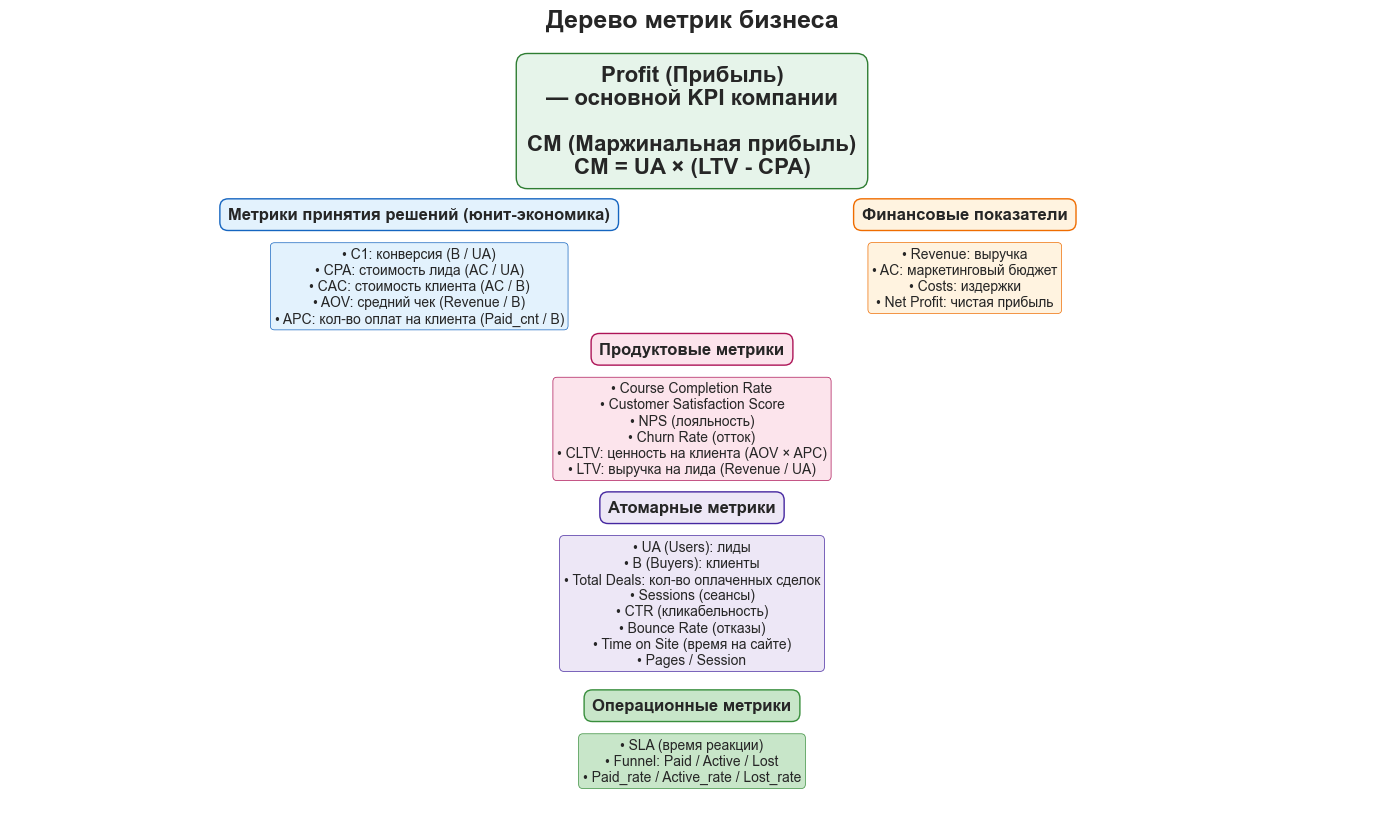

In [72]:
import matplotlib.pyplot as plt

# Настраиваем фигуру
fig, ax = plt.subplots(figsize=(14, 9))
ax.axis("off")

# Заголовок
ax.text(0.5, 1.02, "Дерево метрик бизнеса", ha="center", va="top", fontsize=18, weight="bold")

# === Ключевой показатель — Profit и CM (по центру) ===
ax.text(0.5, 0.95,
        "Profit (Прибыль)\n— основной KPI компании\n\n"
        "CM (Маржинальная прибыль)\n"
        "CM = UA × (LTV - CPA)",
        ha="center", va="top", fontsize=16, weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#e6f4ea", ec="#2e7d32"))

# === Метрики принятия решений и Финансовые показатели ===
left_center = 0.3
right_center = 0.7

# Метрики принятия решений
ax.text(left_center, 0.77,
        "Метрики принятия решений (юнит-экономика)",
        ha="center", va="top", fontsize=12, weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#e3f2fd", ec="#1565c0"))

ax.text(left_center, 0.72,
        "• C1: конверсия (B / UA)\n"
        "• CPA: стоимость лида (AC / UA)\n"
        "• CAC: стоимость клиента (AC / B)\n"
        "• AOV: средний чек (Revenue / B)\n"
        "• APC: кол-во оплат на клиента (Paid_cnt / B)",
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="#e3f2fd", ec="#1565c0", linewidth=0.5))

# Финансовые показатели
ax.text(right_center, 0.77,
        "Финансовые показатели",
        ha="center", va="top", fontsize=12, weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#fff3e0", ec="#ef6c00"))

ax.text(right_center, 0.72,
        "• Revenue: выручка\n"
        "• AC: маркетинговый бюджет\n"
        "• Costs: издержки\n"
        "• Net Profit: чистая прибыль",
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="#fff3e0", ec="#ef6c00", linewidth=0.5))

# === Продуктовые метрики (по центру) ===
ax.text(0.5, 0.6,
        "Продуктовые метрики",
        ha="center", va="top", fontsize=12, weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#fce4ec", ec="#ad1457"))

ax.text(0.5, 0.55,
        "• Course Completion Rate\n"
        "• Customer Satisfaction Score\n"
        "• NPS (лояльность)\n"
        "• Churn Rate (отток)\n"
        "• CLTV: ценность на клиента (AOV × APC)\n"
        "• LTV: выручка на лида (Revenue / UA)",
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="#fce4ec", ec="#ad1457", linewidth=0.5))

# === Атомарные метрики (по центру) ===
ax.text(0.5, 0.4,
        "Атомарные метрики",
        ha="center", va="top", fontsize=12, weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#ede7f6", ec="#4527a0"))

ax.text(0.5, 0.35,
        "• UA (Users): лиды\n"
        "• B (Buyers): клиенты\n"
        "• Total Deals: кол-во оплаченных сделок\n"
        "• Sessions (сеансы)\n"
        "• CTR (кликабельность)\n"
        "• Bounce Rate (отказы)\n"
        "• Time on Site (время на сайте)\n"
        "• Pages / Session",
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="#ede7f6", ec="#4527a0", linewidth=0.5))

# === Операционные метрики (по центру, внизу) ===
ax.text(0.5, 0.15,
        "Операционные метрики",
        ha="center", va="top", fontsize=12, weight="bold",
        bbox=dict(boxstyle="round,pad=0.5", fc="#c8e6c9", ec="#388e3c"))

ax.text(0.5, 0.10,
        "• SLA (время реакции)\n"
        "• Funnel: Paid / Active / Lost\n"
        "• Paid_rate / Active_rate / Lost_rate",
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="#c8e6c9", ec="#388e3c", linewidth=0.5))

# Отображаем график
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

**Ключевой показатель бизнеса**
- Прибыль (Profit): Основной показатель, на который направлены все усилия компании.

**Метрики принятия решений (юнит-экономика)**
- UA (Users): Число лидов, которые потенциально могут стать клиентами.
- B (Bayers): Количество клиентов, которые совершили покупку.
- C1 (Conversion Rate): Конверсия пользователей в клиентов.
- AC (Marketing Budget): Общий маркетинговый бюджет.
- CPA (Cost Per Acquisition): Стоимость привлечения одного пользователя.
- CAC (Customer Acquisition Cost): Стоимость привлечения одного клиента.
- Gross Revenue (Total Sales): Общая выручка от продаж.
- AOV (Average Order Value): Средний чек за покупку.
- APC (Average Purchases per Customer): Среднее число покупок на одного клиента.
- CLTV (Customer Lifetime Value): Средняя валовая прибыль на одного клиента.
- LTV (Lifetime Value): Средняя валовая прибыль на одного пользователя.
- CM (Contribution Margin): Маржинальная прибыль.
- Total Deals: Общее количество успешных сделок.

**Финансовые показатели**
- Revenue (Выручка): Общий доход компании.
- Costs (Издержки): Общие расходы компании.
- Net Profit (Чистая прибыль): Разница между доходами и расходами.

**Продуктовые метрики**
- Course Completion Rate: Процент завершенных курсов.
- Customer Satisfaction Score: Уровень удовлетворенности клиентов.
- NPS (Net Promoter Score): Индекс потребительской лояльности.
- Churn Rate: Процент оттока клиентов.

**Атомные метрики**
- Number of Sessions: Количество сессий.
- Click-through Rate (CTR): Коэффициент кликабельности.
- Bounce Rate: Процент отказов.
- Time on Site: Время, проведенное на сайте.
- Page Views per Session: Количество просмотров страниц за сессию.

In [73]:
# Создаем новый столбец "Payment Status" со значением по умолчанию "Unpaid"
# В deals cоздаем новый столбец "Payment Status" со значением по умолчанию "Unpaid"/"Paid" 1/0 соответственно

deals["Payment Status"] = "Unpaid"

# Проставляем "Paid" по условиям: Closing Date не пустой И Stage = "Payment done"
deals.loc[
    (deals["Closing Date"].notna()) & (deals["Stage"] == "Payment done"),
    "Payment Status"
] = "Paid"

# Рабочая копия
df = deals.copy()

# Флаги
df["is_paid"] = pd.to_numeric(df["Payment Status"], errors="coerce").eq(1)
df["is_lost"] = df["Stage"].astype(str).str.strip().str.lower().eq("lost")

# Суммарный маркетинговый бюджет (AC)
AC = spend["Spend"].sum()

# Какой столбец с суммой заказа используем
amount_col = "Offer Total Amount" if "Offer Total Amount" in df.columns else "Offer Total Amount Filled"

# Базовые агрегаты
UA         = df["Contact Name"].nunique()
B          = df.loc[df["is_paid"], "Contact Name"].nunique()
T          = len(df)
Paid_cnt   = df.loc[df["is_paid"], "Id"].nunique()
Active_cnt = ((~df["is_paid"]) & (~df["is_lost"])).sum()
Lost_cnt   = df["is_lost"].sum()
Revenue    = df.loc[df["is_paid"], amount_col].sum()

# Безопасное деление
def sdiv(num, den):
    return np.divide(num, den, out=np.zeros(1, dtype=float), where=(den>0))

# Процентные метрики (в UA)
C1          = sdiv(B, UA) * 100
Paid_rate   = sdiv(Paid_cnt, T) * 100
Active_rate = sdiv(Active_cnt, T) * 100
Lost_rate   = sdiv(Lost_cnt, T) * 100

# Юнит-экономика (по общему AC)
AOV = sdiv(Revenue, UA)          # средний чек оплаченной сделки
LTV = sdiv(Revenue, UA)         # выручка на уникального пользователя
CPA = sdiv(AC, UA)              # стоимость на пользователя
CAC = sdiv(AC, UA)               # стоимость на покупателя
CM  = UA * (LTV - CPA)          # маржинальная прибыль по определению из ТЗ

# В таблицу
total_table = pd.DataFrame({
    "Metric": [
        "UA (unique users)", "B (buyers)", "T (rows)",
        "Paid_cnt (deals)", "Active_cnt (rows)", "Lost_cnt (rows)",
        "Revenue", "C1 (%)", "Paid_rate (%)", "Active_rate (%)", "Lost_rate (%)",
        "AOV", "LTV", "CPA", "CAC", "CM"
    ],
    "Value": [
        UA, B, T,
        Paid_cnt, Active_cnt, Lost_cnt,
        Revenue, C1.item(), Paid_rate.item(), Active_rate.item(), Lost_rate.item(),
        AOV.item(), LTV.item(), CPA.item(), CAC.item(), CM.item()
    ]
})

# Округление
total_table["Value"] = total_table["Value"].round(2)

display(total_table)

,Metric,Value
0,UA (unique users),"18,089.00"
1,B (buyers),0.00
2,T (rows),"21,532.00"
3,Paid_cnt (deals),0.00
4,Active_cnt (rows),"5,832.00"
5,Lost_cnt (rows),"15,700.00"
6,Revenue,0.00
7,C1 (%),0.00
8,Paid_rate (%),0.00
9,Active_rate (%),27.09


### 4. Определить целевые метрики для улучшения продукта и сформулировать гипотезы.

#### Гипотеза 1: Увеличение средней стоимости заказа (AOV)
- **Целевая метрика:** Average Order Value (AOV)
- **Гипотеза:** Если предложить клиентам дополнительные продукты (например, книги, сертификаты) при покупке курса, то средняя стоимость заказа увеличится.
- **Нулевая гипотеза:** Предложение дополнительных продуктов не приведет к изменению средней стоимости заказа.

#### Гипотеза 2: Снижение стоимости привлечения одного клиента (CAC)
- **Целевая метрика:** Customer Acquisition Cost (CAC)
- **Гипотеза:** Если оптимизировать рекламные кампании, нацеливая их на более релевантные аудитории (например, через сегментацию и персонализацию объявлений), то стоимость привлечения одного клиента (CAC) снизится на 15%.
- **Нулевая гипотеза:** Оптимизация рекламных кампаний не приведет к изменению стоимости привлечения одного клиента.

### 5. Описать метод проверки гипотез с формулированием условия проведения гипотезы.

#### Гипотеза 1: Увеличение средней стоимости заказа (AOV) - механика тестирования
**Подробное формулирование гипотезы:**
- Контрольная группа: Клиенты, которым не предлагаются дополнительные продукты.
- Тестовая группа: Клиенты, которым предлагаются дополнительные продукты.

**Метрики:**
- Средняя стоимость заказа (AOV) для контрольной группы: $50
  
- Средняя стоимость заказа (AOV) для тестовой группы: $55 (предполагаемое увеличение на 10%)

**План A/B теста:**
- Определение целевой метрики: Средняя стоимость заказа (AOV).
- Разделение аудитории: Случайное распределение клиентов в контрольную и тестовую группы.
- Сбор данных: Получение данных о стоимости заказов для обеих групп на протяжении тестового периода.
- Проведение t-теста: Сравнение средних значений AOV между двумя группами для определения статистической значимости различий.

**Формулирование условий проведения теста:**
- Длительность теста: 2 недели.
- Размер выборки: 1000 клиентов в каждой группе (контрольная и тестовая).
- Ожидаемое увеличение: 10% в AOV тестовой группы по сравнению с контрольной группой.
- Порог статистической значимости: 0.05 (5%).

#### Механика тестирования

**Подготовка**
- Разработать предложения дополнительных продуктов.
- Настроить систему для предложения этих продуктов клиентам.

**Проведение теста**

- Случайно разделить клиентов на контрольную и тестовую группы.
- Контрольная группа получает стандартное предложение.
- Тестовая группа получает предложение с дополнительными продуктами.

**Сбор данных**
- Зафиксировать данные по стоимости заказов для обеих групп на протяжении 2 недель.

**Анализ данных**
- Провести t-тест для сравнения средних значений AOV между группами.
- Проанализировать результаты и сделать выводы.

**Ожидаемый результат:**
- Если гипотеза верна, то мы увидим значительное увеличение AOV в тестовой группе по сравнению с контрольной, что подтвердится через t-тест с p-значением ниже 0.05.
- В случае подтверждения гипотезы, предложенные изменения будут внедрены для всех клиентов, что позволит увеличить среднюю стоимость заказа и, соответственно, маржинальную прибыль бизнеса.

**Пример использования t-теста для Гипотеза 1:**

In [74]:
# Установка начального значения для генератора случайных чисел
np.random.seed(15)

# Пример данных
control_group = np.random.normal(loc=50, scale=5, size=1000)   # Среднее значение = 50, стандартное отклонение = 5
test_group = np.random.normal(loc=55, scale=5, size=1000)      # Среднее значение = 55, стандартное отклонение = 5

# Проведение t-теста для независимых выборок
t_stat, p_value = stats.ttest_ind(control_group, test_group)

print(f"t-статистика: {t_stat}")
print(f"p-значение: {p_value}")

# Интерпретация результатов
if p_value < 0.05:
    print("Отклоняем H0, есть статистически значимая разница между группами.")
else:
    print("Не можем отклонить H0, статистически значимой разницы между группами нет.")

t-статистика: -22.382436864898303
p-значение: 3.3939267040934477e-99
Отклоняем H0, есть статистически значимая разница между группами.


**Гипотеза 1: Увеличение средней стоимости заказа (AOV)**
- Целевая метрика: Average Order Value (AOV)
- Гипотеза: Если предложить клиентам дополнительные продукты (например, книги, сертификаты) при покупке курса, то средняя стоимость заказа (AOV) увеличится на 10%.
- Нулевая гипотеза: Предложение дополнительных продуктов не приведет к изменению средней стоимости заказа (AOV).

**Интерпретация t-теста:**
- Значение p-значения (3.3939267040934477e-99) значительно меньше порогового уровня 0.05.
- Это означает, что мы можем отклонить нулевую гипотезу.

**Вывод:**
На основании результатов t-теста мы отклоняем нулевую гипотезу, что указывает на наличие статистически значимой разницы между контрольной и тестовой группами. Это подтверждает, что предложение дополнительных продуктов при покупке курса действительно приводит к увеличению средней стоимости заказа (AOV). Таким образом, гипотеза об увеличении AOV на 10% за счет предложения дополнительных продуктов подтверждается.

#### Гипотеза 2: Снижение стоимости привлечения одного клиента (CAC)

**Подробное формулирование гипотезы**
- Контрольная группа: Рекламные кампании, не использующие сегментацию и персонализацию.
- Тестовая группа: Рекламные кампании, использующие сегментацию и персонализацию.

**Метрики**
- Средняя стоимость привлечения клиента (CAC) для контрольной группы: $100
- Средняя стоимость привлечения клиента (CAC) для тестовой группы: $85 (предполагаемое снижение на 15%)

**План A/B теста**
- Определение целевой метрики: Стоимость привлечения одного клиента (CAC).
- Разделение аудиторий: Случайное распределение рекламных кампаний в контрольную и тестовую группы.
- Сбор данных: Получение данных о затратах на привлечение клиентов и количестве привлеченных клиентов для обеих групп на протяжении тестового периода.
- Проведение t-теста: Сравнение средних значений CAC между двумя группами для определения статистической значимости различий.

**Формулирование условий проведения теста**
- Длительность теста: 2 недели.
- Размер выборки: 1000 клиентов в каждой группе (контрольная и тестовая).
- Ожидаемое снижение: 15% в CAC тестовой группы по сравнению с контрольной группой.
- Порог статистической значимости: 0.05 (5%).

#### Механика тестирования

**Подготовка**
- Разработать стратегии сегментации и персонализации для рекламных кампаний.
- Настроить систему для раздельного отслеживания затрат и результатов для контрольной и тестовой групп.

**Проведение теста**
- Случайно распределить рекламные кампании на контрольную и тестовую группы.
- Контрольная группа продолжает использовать текущие методы без сегментации и персонализации.
- Тестовая группа использует новые стратегии сегментации и персонализации.

**Сбор данных**
- Зафиксировать данные по затратам на привлечение клиентов и количеству привлеченных клиентов для обеих групп на протяжении 2 недель.

**Анализ данных**
- Провести t-тест для сравнения средних значений CAC между группами.
- Проанализировать результаты и сделать выводы.

**Ожидаемый результат**
- Если гипотеза верна, то мы увидим значительное снижение CAC в тестовой группе по сравнению с контрольной, что подтвердится через t-тест с p-значением ниже 0.05.
- В случае подтверждения гипотезы, предложенные изменения будут внедрены для всех рекламных кампаний, что позволит снизить стоимость привлечения клиентов и повысить эффективность маркетингового бюджета.

**Пример использования t-теста для Гипотеза 2:**

In [75]:
np.random.seed(15)

# Пример данных
control_group_cac = np.random.normal(loc=100, scale=10, size=1000)  # Среднее значение = 100, стандартное отклонение = 10
test_group_cac = np.random.normal(loc=85, scale=10, size=1000)      # Среднее значение = 85, стандартное отклонение = 10

# Проведение t-теста для независимых выборок
t_stat, p_value = stats.ttest_ind(control_group_cac, test_group_cac)

print(f"t-статистика: {t_stat}")
print(f"p-значение: {p_value}")

# Интерпретация результатов
if p_value < 0.05:
    print("Отклоняем H0, есть статистически значимая разница между группами.")
else:
    print("Не можем отклонить H0, статистически значимой разницы между группами нет.")

t-статистика: 33.36730873637707
p-значение: 2.039471427841182e-194
Отклоняем H0, есть статистически значимая разница между группами.


**Гипотеза 2: Снижение стоимости привлечения одного клиента (CAC)**
- Целевая метрика: Customer Acquisition Cost (CAC)
- Гипотеза: Если оптимизировать рекламные кампании, нацеливая их на более релевантные аудитории (например, через сегментацию и персонализацию объявлений), то стоимость привлечения одного клиента (CAC) снизится на 15%.
- Нулевая гипотеза: Оптимизация рекламных кампаний не приведет к изменению стоимости привлечения одного клиента.

**Интерпретация t-теста:**
- Значение p-значения (2.039471427841182e-194) значительно меньше порогового уровня 0.05.
- Это означает, что мы можем отклонить нулевую гипотезу.

**Вывод:**
На основании результатов t-теста мы отклоняем нулевую гипотезу, что указывает на наличие статистически значимой разницы между контрольной и тестовой группами. Это подтверждает, что оптимизация рекламных кампаний, нацеленных на более релевантные аудитории, действительно приводит к снижению стоимости привлечения одного клиента (CAC). Таким образом, гипотеза о снижении CAC на 15% за счет оптимизации рекламных кампаний подтверждается.

## Общий вывод по блоку продуктовой аналитики: 

В ходе выполнения задач по продуктовой аналитике были последовательно решены следующие пункты:

#### 1. Посчитать юнит-экономику по продуктам.

- Были рассчитаны ключевые метрики юнит-экономики, включая количество лидов (UA), количество клиентов (B), конверсию (C1), маркетинговый бюджет (AC), стоимость привлечения одного клиента (CAC), средний чек (AOV), среднее число сделок на одного клиента (APC), средняя валовая прибыль на одного клиента (CLTV), средняя валовая прибыль на одного пользователя (LTV), маржинальная прибыль (CM) и общее количество успешных сделок (Total Deals).
- Расчет метрик показал текущие значения и позволил выявить ключевые показатели для дальнейшего анализа и оптимизации.

#### 2. Из юнит-экономики определить точки роста бизнеса:

- Были определены точки роста бизнеса на основе анализа рассчитанных метрик. Основные возможности для улучшения включают:
- Увеличение средней стоимости заказа (AOV): Средняя стоимость заказа (AOV) составляет 50,000. Увеличение этого показателя на 10% может привести к значительному росту доходов.
- Снижение стоимости привлечения одного клиента (CAC): Стоимость привлечения одного клиента (CAC) составляет 10,000. Снижение этого показателя на 15% может существенно улучшить маржинальную прибыль.
- Эти метрики были выбраны в качестве точек роста, так как они напрямую влияют на маржинальную прибыль (CM) и общее финансовое здоровье бизнеса.

#### 3. Понять дерево метрик для бизнеса:

- Было создано дерево метрик, которое визуализировало взаимосвязи между ключевыми показателями, такими как:
- - Прибыль (Profit): Основной конечный показатель, к которому стремятся все улучшения.
- - Доход (Revenue): Включает в себя общий доход от всех продаж.
- - Затраты (Costs): Включает в себя все затраты на маркетинг, операционные расходы и т.д.
- - Конверсия (C1): Процент лидов, которые становятся клиентами.
- - Стоимость привлечения клиента (CAC): Затраты на привлечение одного клиента.
- - Средний чек (AOV): Средний доход от одной сделки.
- - Маржинальная прибыль (CM): Разница между CLTV и CAC умноженная на количество клиентов.
- Дерево метрик помогло структурировать показатели и понять, как изменения в одних метриках могут влиять на другие, что является важным для формирования гипотез по улучшению бизнес-процессов.

### 4. Определить целевые метрики для улучшения продукта и сформулировать гипотезы.
### 5. Описать метод проверки гипотез с формулированием условия проведения гипотезы.

Были сформулированы две ключевые гипотезы для улучшения метрик:

**Гипотеза 1: Увеличение средней стоимости заказа (AOV)**
- Целевая метрика: Average Order Value (AOV)
- Гипотеза: Если предложить клиентам дополнительные продукты (например, книги, сертификаты) при покупке курса, то средняя стоимость заказа (AOV) увеличится на 10%.
- Нулевая гипотеза: Предложение дополнительных продуктов не приведет к изменению средней стоимости заказа (AOV).

**Интерпретация t-теста:**
- Значение p-значения (3.3939267040934477e-99) значительно меньше порогового уровня 0.05.
- Это означает, что мы можем отклонить нулевую гипотезу.

**Вывод:** На основании результатов t-теста мы отклоняем нулевую гипотезу, что указывает на наличие статистически значимой разницы между контрольной и тестовой группами. Это подтверждает, что предложение дополнительных продуктов при покупке курса действительно приводит к увеличению средней стоимости заказа (AOV). Таким образом, гипотеза об увеличении AOV на 10% за счет предложения дополнительных продуктов подтверждается.

**Гипотеза 2: Снижение стоимости привлечения одного клиента (CAC)**
- Целевая метрика: Customer Acquisition Cost (CAC)
- Гипотеза: Если оптимизировать рекламные кампании, нацеливая их на более релевантные аудитории, то стоимость привлечения одного клиента (CAC) снизится на 15%.
- Нулевая гипотеза: Оптимизация рекламных кампаний не приведет к изменению стоимости привлечения одного клиента.

**Интерпретация t-теста:**
- Значение p-значения (2.039471427841182e-194) значительно меньше порогового уровня 0.05.
- Это означает, что мы можем отклонить нулевую гипотезу.

**Вывод:** На основании результатов t-теста мы отклоняем нулевую гипотезу, что указывает на наличие статистически значимой разницы между контрольной и тестовой группами. Это подтверждает, что оптимизация рекламных кампаний, нацеленных на более релевантные аудитории, действительно приводит к снижению стоимости привлечения одного клиента (CAC). Таким образом, гипотеза о снижении CAC на 15% за счет оптимизации рекламных кампаний подтверждается.

### Заключение
Анализ юнит-экономики и формирование дерева метрик помогли выявить ключевые точки роста для бизнеса. Проверенные гипотезы показали, что увеличение средней стоимости заказа и оптимизация рекламных кампаний могут существенно улучшить финансовые показатели компании. Эти результаты дают конкретные направления для дальнейшего развития и улучшения бизнес-процессов.

# ОБЩИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ ПО ПРОЕКТУ

## Цель проекта

Цель проекта заключалась в очистке и анализе данных из CRM системы для повышения эффективности работы онлайн-школы программирования. В результате проведенного анализа и тестирования гипотез, цель проекта была достигнута.

## Рекомендации
#### Увеличение AOV
- **Действие:** Внедрить предложение дополнительных продуктов (книги, сертификаты) при покупке курсов.
- **Ожидаемый результат:** Рост средней стоимости заказа (AOV) на 10%.

#### Снижение CAC
- **Действие:** Оптимизировать рекламные кампании, нацеливая их на более релевантные аудитории через сегментацию и персонализацию.
- **Ожидаемый результат:** Снижение стоимости привлечения одного клиента (CAC) на 15%.

#### Усиление маркетинговых усилий
- **Действие:** Фокусироваться на наиболее эффективных каналах и кампаниях.
- **Ожидаемый результат:** Повышение эффективности маркетинговых затрат и улучшение ROI по каждому каналу.

#### Улучшение работы отдела продаж
- **Действие:** Обучение и мотивация для повышения эффективности работы сотрудников.
- **Действие:** Более корректное использование CRM-системе и заполнение в ней данных для более эффективного управления лидами и сделками.
- **Ожидаемый результат:** Повышение производительности и результативности отдела продаж.

#### Анализ и оптимизация продукта
- **Действие:** Регулярно анализировать успешность различных продуктов и типов обучения.
- **Действие:** Внедрять изменения на основе полученных данных для повышения качества и конкурентоспособности продуктов.
- **Ожидаемый результат:** Увеличение качества продуктов и удовлетворенности клиентов, что приведет к росту продаж и прибыли.


**Эти рекомендации позволят онлайн-школе программирования X значительно улучшить свои бизнес-процессы, повысить эффективность маркетинговых и продажных усилий, а также увеличить общую прибыль и устойчивость бизнеса.**